# 2x2 Matrix Analysis -- Antibody Therapeutics IP x Clinical (Oncology)
**Prepared for:** Executive / Program Strategy Review
**Analyst view:** Head of Data Analytics -- target/modality selection for a new antibody-therapeutics program
**Sources:** `input/ip_final_version4.csv` (patents) x `input/clinical_final_version1.csv` (trials)
**Engine:** `input/multitarget_locked_whitespace_workflow.py` (reused verbatim, deterministic, no LLM)
**Join key:** `target_harmonized` only (per instruction)

**Plan:** Entry 1-4 build the shared data + methodology. Entry 5-9 pilot the pipeline on **Pancreatic**.
Entry 10-11 generalize it into a reusable runner and demonstrate it on **Prostate**. Entry 12-13 sweep
every remaining named solid tumor type (ranked by trial volume, with 1L/2L cuts where volume
supports it). Entry 14 runs the **whole dataset** as one cut. Entry 15 is the cross-cut executive
synthesis / portfolio shortlist.

## Entry 1: Setup, Scope & Data Load

In [1]:
# Executive framing ------------------------------------------------------
# Question: where should we place our antibody-therapeutics oncology bet?
# X axis = freedom-to-operate / epitope-IP crowding (from patents).
# Y axis = clinical validation signal (from trials).
# Join key: target_harmonized (curated taxonomy), present in BOTH files.
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE VIEW raw_ip AS SELECT * FROM read_csv_auto('{IP_CSV}', ALL_VARCHAR=FALSE, SAMPLE_SIZE=-1)")
con.execute(f"CREATE OR REPLACE VIEW raw_clin AS SELECT * FROM read_csv_auto('{CLIN_CSV}', ALL_VARCHAR=FALSE, SAMPLE_SIZE=-1)")
ip_raw = con.sql("SELECT * FROM raw_ip").df()
clin_raw = con.sql("SELECT * FROM raw_clin").df()
print(f"IP master   : {len(ip_raw):,} rows x {ip_raw.shape[1]} cols   ({ip_raw['target_harmonized'].nunique():,} distinct target_harmonized)")
print(f"Clinical    : {len(clin_raw):,} rows x {clin_raw.shape[1]} cols   ({clin_raw['target_harmonized'].nunique():,} distinct target_harmonized)")
print()
print("IP  is_antibody distribution:", dict(ip_raw["is_antibody"].value_counts(dropna=False)))
print("Clinical in_scope distribution:", dict(clin_raw["in_scope"].value_counts(dropna=False)))

IP master   : 4,005 rows x 72 cols   (1,123 distinct target_harmonized)
Clinical    : 19,357 rows x 63 cols   (1,692 distinct target_harmonized)

IP  is_antibody distribution: {True: np.int64(4000), False: np.int64(5)}
Clinical in_scope distribution: {np.True_: np.int64(16648), np.False_: np.int64(2684), <NA>: np.int64(25)}


## Entry 2: Scoping Filters -- Antibody-Only IP & In-Scope Clinical Trials

In [2]:
# Keep only antibody-format patents on the IP side, and only in_scope
# (curated antibody-modality oncology) trials on the clinical side --
# matches the scoping already applied throughout the other notebooks in
# this project. Both `is_antibody` and `in_scope` are DuckDB-inferred
# real nullable booleans, so compare with `== True`, not a string.
ip_scoped = ip_raw[ip_raw["is_antibody"] == True].copy()  # noqa: E712
clin_scoped = clin_raw[clin_raw["in_scope"] == True].copy()  # noqa: E712

# Data-quality fix: `application_date` / `filing_year` in this source file are stored
# as float-like text ("20100330.0", "2010.0") -- the workflow engine's `_ip_apd()`
# requires pure digit strings (isdigit()) to parse them, so a trailing ".0" silently
# makes EVERY patent's application date unparseable -> 0 grounded patents ever counted.
# Strip the spurious ".0" suffix once here, upstream of the (unmodified) engine.
for _col in ["application_date", "filing_year"]:
    ip_scoped[_col] = (ip_scoped[_col].astype(str)
                       .str.replace(r"\.0$", "", regex=True)
                       .replace({"nan": ""}))

os.makedirs(os.path.join(RUNS_DIR, "_shared"), exist_ok=True)
IP_SCOPED_CSV = os.path.join(RUNS_DIR, "_shared", "ip_final_version4_antibody_only.csv")
ip_scoped.to_csv(IP_SCOPED_CSV, index=False)

print(f"IP:       {len(ip_raw):,} -> {len(ip_scoped):,} rows kept (is_antibody == 'yes')")
print(f"Clinical: {len(clin_raw):,} -> {len(clin_scoped):,} rows kept (in_scope == True)")
print(f"Scoped IP file written: {IP_SCOPED_CSV}")

IP:       4,005 -> 4,000 rows kept (is_antibody == 'yes')
Clinical: 19,357 -> 16,648 rows kept (in_scope == True)
Scoped IP file written: /Users/revathisekar/Documents/vibe analytics trial 2/output/2by2 matrix_ip_clinical/workflow_runs/_shared/ip_final_version4_antibody_only.csv


## Entry 3: Tumor-Type Classifier (reused from the clinical-landscape notebooks)

In [3]:
# No curated tumor-type column exists in the clinical file, so we reuse
# the same ordered keyword/regex classifier already validated in
# build_clinical_landscape_notebook.py -- most-specific categories first
# (e.g. NSCLC before generic "lung"). A trial can carry multiple tags
# (basket trials); tumor_primary = first (most specific) match.
TUMOR_CATEGORIES = [
    ("NSCLC", r"non[- ]?small[- ]?cell lung|nsclc"),
    ("SCLC", r"small[- ]?cell lung (carcinoma|cancer)|\bsclc\b"),
    ("Lung_Other", r"\blung\b|pulmonary"),
    ("Breast", r"\bbreast\b"),
    ("Ovarian", r"ovarian|\bovary\b"),
    ("Endometrial_Uterine", r"endometrial|\buterine\b"),
    ("Cervical", r"cervical|\bcervix\b"),
    ("Colorectal", r"colorectal|\bcolon\b|\brectal\b|\brectum\b"),
    ("Gastric_Esophageal", r"gastric|\bstomach\b|esophageal|oesophageal|gastroesophageal|\bgej\b"),
    ("Hepatocellular", r"hepatocellular|\bhcc\b"),
    ("Biliary_Cholangio", r"cholangiocarcinoma|\bbiliary\b"),
    ("Pancreatic", r"pancreatic|\bpancreas\b"),
    ("RCC", r"renal cell|\brcc\b|kidney cancer"),
    ("Bladder_Urothelial", r"\bbladder\b|urothelial"),
    ("Prostate", r"prostat"),
    ("Melanoma", r"melanoma"),
    ("HNSCC", r"head and neck|nasopharyngeal|oropharyngeal|laryngeal|hypopharyngeal|oral cavity"),
    ("Glioma_CNS", r"glioma|glioblastoma|astrocytoma|central nervous system|\bcns\b|brain (tumou?r|neoplasm)"),
    ("Mesothelioma", r"mesothelioma"),
    ("Sarcoma", r"sarcoma"),
    ("Thyroid", r"thyroid"),
    ("Skin_NonMelanoma", r"squamous cell carcinoma of the skin|cutaneous squamous|basal cell carcinoma|merkel cell"),
    ("Neuroendocrine", r"neuroendocrine|carcinoid"),
    ("GermCell_Testicular", r"testicular|germ cell"),
    ("Adrenal", r"adrenocortical|adrenal"),
    ("Salivary_Gland", r"salivary gland"),
    ("Solid_Tumor_Basket", r"solid tumou?r|advanced cancer|advanced malignant neoplasm|\bany cancer\b|metastatic cancer|metastatic solid"),
    ("Hematologic_Lymphoma", r"lymphoma"),
    ("Hematologic_Leukemia", r"leuk[ae]mia"),
    ("Hematologic_Myeloma", r"myeloma"),
    ("Hematologic_MDS_MPN", r"myelodysplastic|myeloproliferative"),
]
COMPILED = [(name, re.compile(pat, re.IGNORECASE)) for name, pat in TUMOR_CATEGORIES]

def classify_tumor_tags(cond_text):
    if not cond_text or pd.isna(cond_text):
        return []
    return [name for name, rx in COMPILED if rx.search(str(cond_text))]

clin_scoped["condition_text"] = clin_scoped["ctgov_conditions"].fillna(clin_scoped["m_conditions"])
clin_scoped["tumor_tags"] = clin_scoped["condition_text"].apply(classify_tumor_tags)
clin_scoped["tumor_primary"] = clin_scoped["tumor_tags"].apply(lambda t: t[0] if t else None)
clin_scoped["tumor_primary"] = clin_scoped["tumor_primary"].where(
    clin_scoped["tumor_primary"].notna(),
    np.where(clin_scoped["condition_text"].notna(), "Other_Unclassified", "No_Condition_Data"),
)

tumor_volume = clin_scoped["tumor_primary"].value_counts().head(25).to_frame("n_trials")
print("Top tumor types by in-scope trial volume (preview for Phase 2 sequencing):")
display(tumor_volume, name="entry03_tumor_type_volume_preview")

Top tumor types by in-scope trial volume (preview for Phase 2 sequencing):


,n_trials
tumor_primary,
NSCLC,2355
Hematologic_Lymphoma,1939
Breast,1820
Other_Unclassified,1351
Colorectal,1101
Solid_Tumor_Basket,1014
Gastric_Esophageal,761
Hematologic_Leukemia,745
Lung_Other,632


## Entry 4: Methodology -- Deterministic 2x2 Whitespace Engine

In [4]:
print("Engine: input/multitarget_locked_whitespace_workflow.py (imported verbatim, un-modified).")
print()
print("X axis -- epitope_crowding_X in [0,1] (0 = open, 1 = crowded):")
print("  3 weighted layers from patent claims -- L1 cross-modality epitope lock (hard floor),")
print("  L2 modality-specific claim density, L3 indication-specific use/combo claim density.")
print(f"  Layer weights: L1={MTW.W.FTO_W_L1}  L2={MTW.W.FTO_W_L2}  L3={MTW.W.FTO_W_L3}   (L1 hard floor: {MTW.W.FTO_L1_IS_HARD_FLOOR})")
print()
print("Y axis -- clinical_performance_Y in [0,1] (0 = failed, 1 = validated):")
print("  Phase-weighted net outcome across decisive trials (approved/positive/negative/terminated),")
print(f"  squashed with tanh; positive Phase 3+ readout floors Y at 0.75. Phase weights: {MTW.W.PHASE_WEIGHT}")
print()
print(f"Quadrant split point (both axes): {MTW.W.PERF_SPLIT}")
print("  Y hi & X open    -> TRUE WHITE SPACE   (validated biology, room to build IP position)")
print("  Y hi & X crowded -> BATTLEGROUND       (validated biology, contested IP)")
print("  Y lo & X open    -> R&D TRAP           (unproven biology, IP looks open -- proceed with caution)")
print("  Y lo & X crowded -> RED FLAGS          (unproven biology AND contested IP -- avoid)")
print()
print(f"Join key: '{MTW.DEF_KEY_COL}' (verbatim, case/space-normalized) -- per instruction, NOT split by modality.")
print("Node granularity for this analysis: one node per target_harmonized (modality collapsed, by_modality=False).")

Engine: input/multitarget_locked_whitespace_workflow.py (imported verbatim, un-modified).

X axis -- epitope_crowding_X in [0,1] (0 = open, 1 = crowded):
  3 weighted layers from patent claims -- L1 cross-modality epitope lock (hard floor),
  L2 modality-specific claim density, L3 indication-specific use/combo claim density.
  Layer weights: L1=0.55  L2=0.25  L3=0.2   (L1 hard floor: True)

Y axis -- clinical_performance_Y in [0,1] (0 = failed, 1 = validated):
  Phase-weighted net outcome across decisive trials (approved/positive/negative/terminated),
  squashed with tanh; positive Phase 3+ readout floors Y at 0.75. Phase weights: {<Phase.PH1: 1>: 0.15, <Phase.PH2: 2>: 0.45, <Phase.PH3: 3>: 0.85, <Phase.APPROVAL: 4>: 1.0}

Quadrant split point (both axes): 0.5
  Y hi & X open    -> TRUE WHITE SPACE   (validated biology, room to build IP position)
  Y hi & X crowded -> BATTLEGROUND       (validated biology, contested IP)
  Y lo & X open    -> R&D TRAP           (unproven biology, IP loo

## Entry 5 [PILOT]: Pancreatic Tumor -- 2x2 Placement

In [5]:
PILOT_DIR = os.path.join(RUNS_DIR, "pancreatic")
os.makedirs(PILOT_DIR, exist_ok=True)

clin_pancreatic = clin_scoped[clin_scoped["tumor_primary"] == "Pancreatic"].copy()
CLIN_PANC_CSV = os.path.join(PILOT_DIR, "clinical_input_filtered_pancreatic.csv")
clin_pancreatic.drop(columns=["tumor_tags"]).to_csv(CLIN_PANC_CSV, index=False)
print(f"Pancreatic in-scope clinical rows: {len(clin_pancreatic):,} "
      f"({clin_pancreatic['target_harmonized'].nunique():,} distinct targets)")

IP_SCOPED_CSV = os.path.join(RUNS_DIR, "_shared", "ip_final_version4_antibody_only.csv")
pilot_rows = MTW.run(
    ip_csv=IP_SCOPED_CSV, clin_csv=CLIN_PANC_CSV, as_of=MTW.DEF_AS_OF,
    indication_terms=["pancreatic", "pancreas"], outdir=PILOT_DIR,
    key_col="target_harmonized", mod_col="modality_code",
    by_modality=False, sample_n=0, seed=7,
)
pancreatic_master = pd.DataFrame(pilot_rows)
print()
print(f"Total target_harmonized nodes considered: {len(pancreatic_master)}")
print(f"Placed on both axes (real 2x2 members): {int((pancreatic_master['x_resolved'] & pancreatic_master['y_resolved']).sum())}")

quadrant_counts = (pancreatic_master.groupby("quadrant").size()
                   .reindex(list(MTW.W.ALL_QUADRANTS) + ["UNRESOLVED"], fill_value=0)
                   .to_frame("n_targets"))
display(quadrant_counts, name="pancreatic_quadrant_counts")

Pancreatic in-scope clinical rows: 301 (73 distinct targets)

Total target_harmonized nodes considered: 1177
Placed on both axes (real 2x2 members): 16


,n_targets
quadrant,
TRUE WHITE SPACE,3
BATTLEGROUND,0
R&D TRAP,13
RED FLAGS,0
UNRESOLVED,1161


## Entry 6 [PILOT]: Pancreatic 2x2 -- Quadrant Detail Tables

In [6]:
placed = pancreatic_master[pancreatic_master["x_resolved"] & pancreatic_master["y_resolved"]].copy()
cols = ["target_harmonized", "clinical_performance_Y", "clinical_label", "n_trials",
        "epitope_crowding_X", "patents_grounded", "blocking_assignee", "key_patent"]

for q in MTW.W.ALL_QUADRANTS:
    sub = placed[placed["quadrant"] == q].sort_values("clinical_performance_Y", ascending=False)[cols]
    print(f"--- {q} ({len(sub)} targets) ---")
    display(sub, name=f"pancreatic_quadrant_{re.sub(r'[^A-Za-z0-9]+', '_', q).strip('_').lower()}")

--- TRUE WHITE SPACE (3 targets) ---
--- BATTLEGROUND (0 targets) ---
--- R&D TRAP (13 targets) ---
--- RED FLAGS (0 targets) ---


,target_harmonized,clinical_performance_Y,clinical_label,n_trials,epitope_crowding_X,patents_grounded,blocking_assignee,key_patent
375,CLDN18.2,0.750,VALIDATED,6,0.113,3,BIOSION INC.,WO2023066267A1
837,NECTIN4,0.646,VALIDATED,1,0.000,1,ELPIS BIOPHARMACEUTICALS,WO2023278480A1
909,PD-1|CTLA-4,0.646,VALIDATED,2,0.066,3,FORTVITA BIOLOGICS (SINGAPORE) PTE. LTD.,WO2025140535A1


,target_harmonized,clinical_performance_Y,clinical_label,n_trials,epitope_crowding_X,patents_grounded,blocking_assignee,key_patent


,target_harmonized,clinical_performance_Y,clinical_label,n_trials,epitope_crowding_X,patents_grounded,blocking_assignee,key_patent
265,CD40,0.475,CONTESTED,5,0.042,2,STRIKE PHARMA AB,WO2021239968A1
363,CEA|CEACAM5,0.475,CONTESTED,1,0.000,1,PHILOGEN S.P.A.,WO2024165403A1
612,HER2,0.475,CONTESTED,6,0.185,10,ZYMEWORKS BC INC.,WO2023141714A1
789,MESOTHELIN,0.475,CONTESTED,6,0.000,1,FRED HUTCHINSON CANCER CENTER,WO2021207242A2
813,MUC1,0.450,CONTESTED,2,0.000,1,"DAIICHI SANKYO CO., LTD.",WO2019219891A1
445,DLL3,0.426,CONTESTED,1,0.066,3,"TJ BIOPHARMA (SHANGHAI) CO., LTD.",WO2026067620A1
918,PD-1|PD-L1,0.426,CONTESTED,7,0.154,6,BIOTHEUS INC.,WO2025185733A1
926,PD-L1,0.426,CONTESTED,19,0.196,12,"EXELIXIS, INC.",WO2026030408A1
1059,TCR,0.426,CONTESTED,1,0.000,1,"NANJING LEGEND BIOTECH CO., LTD.",WO2025045018A1
350,CEA,0.362,FAILED / CONTESTED (late),2,0.000,1,"BEIGENE, LTD.",WO2024110905A1


,target_harmonized,clinical_performance_Y,clinical_label,n_trials,epitope_crowding_X,patents_grounded,blocking_assignee,key_patent


## Entry 7 [PILOT]: Pancreatic Watch-Lists -- Partial-Evidence Targets

In [7]:
# Targets resolved on only ONE axis are surfaced as watch-lists (per
# discussion), not dropped -- these are often the earliest-mover signal.
ip_only = pancreatic_master[pancreatic_master["x_resolved"] & ~pancreatic_master["y_resolved"]].copy()
ip_only = ip_only.sort_values(["epitope_crowding_X", "patents_grounded"], ascending=[True, False])
clin_only = pancreatic_master[pancreatic_master["y_resolved"] & ~pancreatic_master["x_resolved"]].copy()
clin_only = clin_only.sort_values("clinical_performance_Y", ascending=False)
neither = pancreatic_master[~pancreatic_master["x_resolved"] & ~pancreatic_master["y_resolved"]]

print(f"Patent-only, clinically untested in pancreatic ({len(ip_only)} targets) -- top 25 by openness:")
display(ip_only[["target_harmonized", "epitope_crowding_X", "patents_grounded", "blocking_assignee", "key_patent"]].head(25),
        name="pancreatic_watchlist_ip_only_patent_untested")

print(f"\\nClinically signaled, IP picture unclear in pancreatic ({len(clin_only)} targets) -- top 25 by performance:")
display(clin_only[["target_harmonized", "clinical_performance_Y", "clinical_label", "n_trials"]].head(25),
        name="pancreatic_watchlist_clinical_only_ip_unclear")

print(f"\\nNeither axis resolved (no grounded pancreatic-relevant patents AND no decisive pancreatic trial readout): {len(neither)} targets")

Patent-only, clinically untested in pancreatic (623 targets) -- top 25 by openness:
\nClinically signaled, IP picture unclear in pancreatic (15 targets) -- top 25 by performance:
\nNeither axis resolved (no grounded pancreatic-relevant patents AND no decisive pancreatic trial readout): 523 targets


,target_harmonized,epitope_crowding_X,patents_grounded,blocking_assignee,key_patent
2,5T4-MMAE,0.0,1,"SALUBRIS BIOTHERAPEUTICS, INC.",WO2024197151A2
3,5T4-MMAF,0.0,1,"SALUBRIS BIOTHERAPEUTICS, INC.",WO2024197151A2
21,ALK|VEGF,0.0,1,"KINTOR PHARMACEUTICAL (GUANGDONG) CO., LTD.",WO2023030433A1
23,ALPP|CD3,0.0,1,"PROMAB BIOTECHNOLOGIES, INC.",WO2021154534A1
33,APLP2|HER2-DM1,0.0,1,"REGENERON PHARMACEUTICALS, INC.",WO2019212965A1
34,APLP2|HER2-DM4,0.0,1,"REGENERON PHARMACEUTICALS, INC.",WO2019212965A1
45,AXL|PD-L1-DOXORUBICIN,0.0,1,CELON PHARMA S.A.,WO2025080151A1
46,AXL|PD-L1-MMAE,0.0,1,CELON PHARMA S.A.,WO2025080151A1
47,AXL|PD-L1-MMAF,0.0,1,CELON PHARMA S.A.,WO2025080151A1
48,AXL|PD-L1-PBD,0.0,1,CELON PHARMA S.A.,WO2025080151A1


,target_harmonized,clinical_performance_Y,clinical_label,n_trials
257,CD3|EGFR,0.769,VALIDATED,4
270,CD40|PD-1,0.646,VALIDATED,1
416,CTLA-4,0.646,VALIDATED,7
501,EGFR|VEGF,0.646,VALIDATED,1
908,PD-1|CEA,0.646,VALIDATED,1
92,BCL-2|CTLA-4|PD-1|PD-L1,0.475,CONTESTED,1
425,CTLA-4|PD-L1,0.475,CONTESTED,2
183,CD19|MESOTHELIN,0.450,CONTESTED,1
261,CD3|MUC1|PD-1,0.426,CONTESTED,1
826,MUC16|MESOTHELIN,0.426,CONTESTED,1


## Entry 8 [PILOT]: Pancreatic 2x2 Scatter Plot

Chart generated by multitarget_locked_whitespace_workflow.py, source: /Users/revathisekar/Documents/vibe analytics trial 2/output/2by2 matrix_ip_clinical/workflow_runs/pancreatic/multitarget_2x2.png


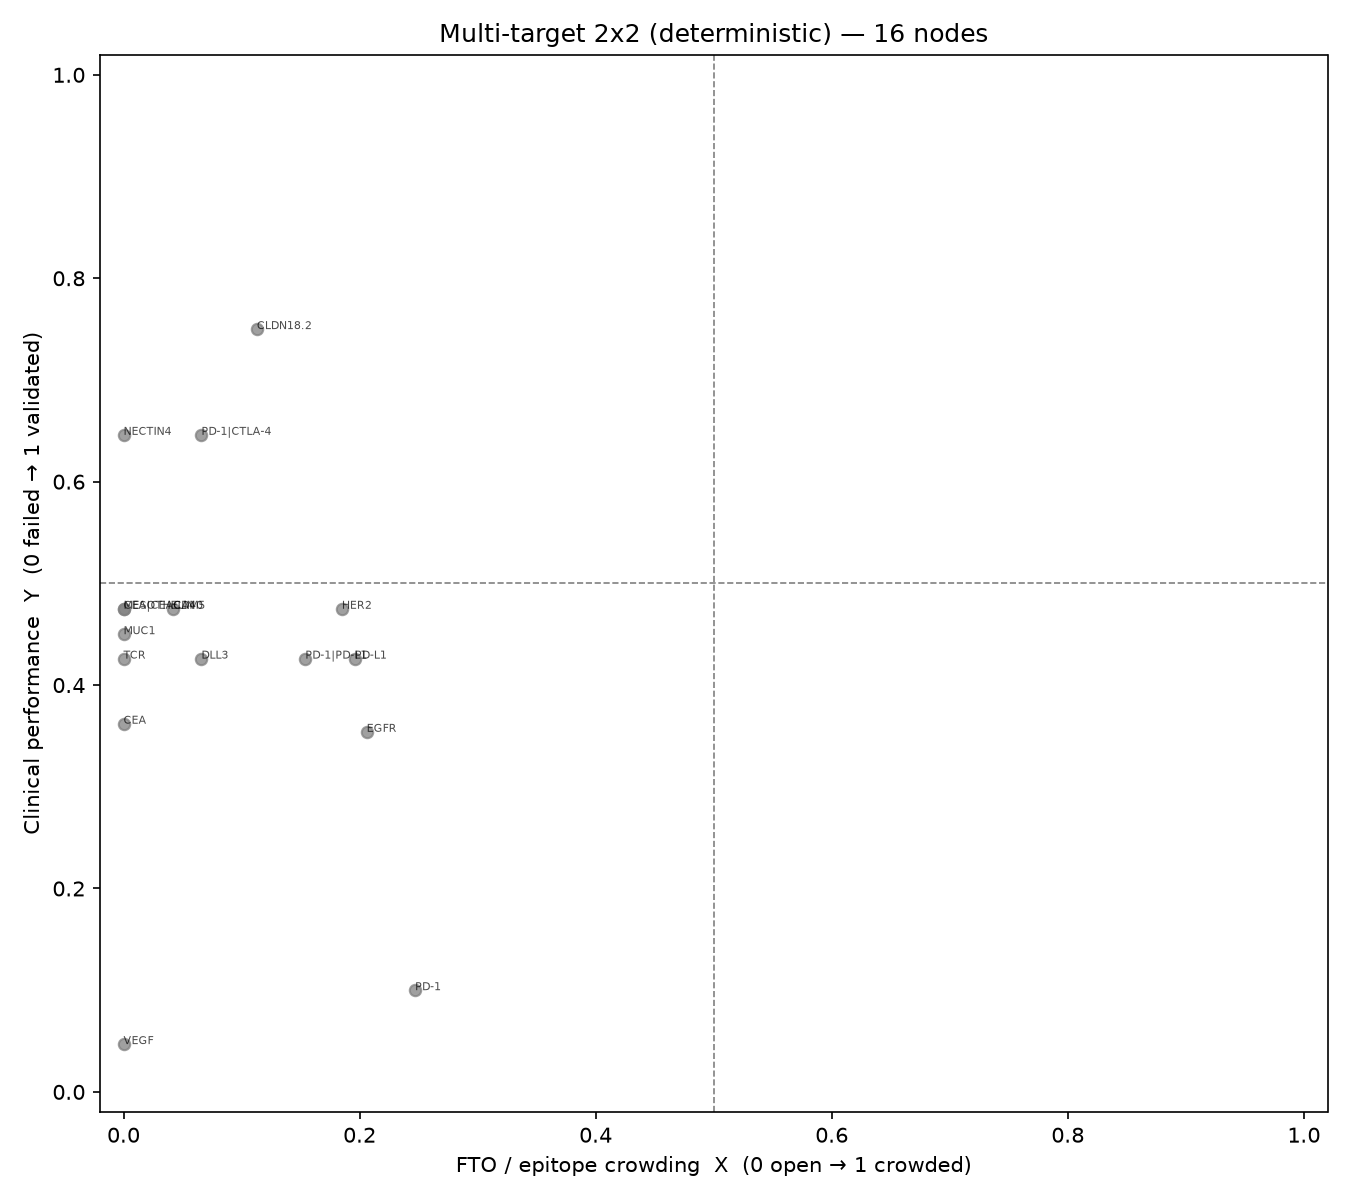

In [8]:
PILOT_DIR = os.path.join(RUNS_DIR, "pancreatic")
embed_png(os.path.join(PILOT_DIR, "multitarget_2x2.png"), name="pancreatic_2x2_scatter")
print(f"Chart generated by multitarget_locked_whitespace_workflow.py, source: {PILOT_DIR}/multitarget_2x2.png")

## Entry 9 [PILOT]: Executive Synthesis -- Pancreatic Pilot

This pilot validated the pipeline end-to-end on one tumor type (join key, scoping filters, quadrant definitions, watch-lists all confirmed). Per go-ahead, Entry 10 onward now generalizes this into a reusable runner, demonstrates it on **Prostate**, then sweeps every remaining named solid tumor type (ranked by trial volume, with 1L/2L cuts where volume supports it) and finally the whole dataset as one run.

In [9]:
placed = pancreatic_master[pancreatic_master["x_resolved"] & pancreatic_master["y_resolved"]]
tws = placed[placed["quadrant"] == "TRUE WHITE SPACE"].sort_values("clinical_performance_Y", ascending=False)
battleground = placed[placed["quadrant"] == "BATTLEGROUND"].sort_values("clinical_performance_Y", ascending=False)
redflags = placed[placed["quadrant"] == "RED FLAGS"]
rdtrap = placed[placed["quadrant"] == "R&D TRAP"]
ip_only_n = int((pancreatic_master["x_resolved"] & ~pancreatic_master["y_resolved"]).sum())
clin_only_n = int((pancreatic_master["y_resolved"] & ~pancreatic_master["x_resolved"]).sum())

print("PANCREATIC PILOT -- EXECUTIVE SUMMARY")
print("=" * 60)
print(f"{len(pancreatic_master)} target_harmonized nodes touch pancreatic cancer across the two datasets;")
print(f"{len(placed)} have BOTH a grounded IP position and a decisive clinical readout and are placed on the 2x2.")
print()
print(f"TRUE WHITE SPACE ({len(tws)}): validated biology, room to build an IP position.")
if len(tws):
    print("  Top candidates: " + ", ".join(tws["target_harmonized"].head(5).tolist()))
print(f"BATTLEGROUND ({len(battleground)}): validated biology, but IP already contested.")
if len(battleground):
    print("  Top candidates: " + ", ".join(battleground["target_harmonized"].head(5).tolist()))
print(f"R&D TRAP ({len(rdtrap)}): open IP but biology unproven in pancreatic -- proceed with caution.")
print(f"RED FLAGS ({len(redflags)}): unproven biology AND contested IP -- avoid.")
print()
print(f"Watch-lists: {ip_only_n} patent-only (no pancreatic clinical readout yet), "
      f"{clin_only_n} clinically-signaled with an unclear pancreatic IP position.")

PANCREATIC PILOT -- EXECUTIVE SUMMARY
1177 target_harmonized nodes touch pancreatic cancer across the two datasets;
16 have BOTH a grounded IP position and a decisive clinical readout and are placed on the 2x2.

TRUE WHITE SPACE (3): validated biology, room to build an IP position.
  Top candidates: CLDN18.2, NECTIN4, PD-1|CTLA-4
BATTLEGROUND (0): validated biology, but IP already contested.
R&D TRAP (13): open IP but biology unproven in pancreatic -- proceed with caution.
RED FLAGS (0): unproven biology AND contested IP -- avoid.

Watch-lists: 623 patent-only (no pancreatic clinical readout yet), 15 clinically-signaled with an unclear pancreatic IP position.


## Entry 10: Reusable Per-Tumor-Type 2x2 Runner

In [10]:
# Generalizes Entry 5-9 into functions so every subsequent tumor-type (and
# line-of-therapy) cut runs through the IDENTICAL logic as the approved
# pancreatic pilot -- same scoping, same engine call, same watch-list
# treatment of partial-evidence targets.

# Approximate free-text indication terms per named solid tumor tag, used
# for the IP engine's L3 "use in THIS indication" layer (substring match
# against the IP file's `indications` free-text column).
TUMOR_INDICATION_TERMS = {
    "NSCLC": ["non-small", "non small", "nsclc", "lung"],
    "SCLC": ["small cell lung", "sclc", "lung"],
    "Lung_Other": ["lung", "pulmonary"],
    "Breast": ["breast"],
    "Ovarian": ["ovarian", "ovary"],
    "Endometrial_Uterine": ["endometrial", "uterine"],
    "Cervical": ["cervical", "cervix"],
    "Colorectal": ["colorectal", "colon", "rectal", "rectum"],
    "Gastric_Esophageal": ["gastric", "stomach", "esophageal", "gastroesophageal"],
    "Hepatocellular": ["hepatocellular", "hcc"],
    "Biliary_Cholangio": ["cholangiocarcinoma", "biliary"],
    "Pancreatic": ["pancreatic", "pancreas"],
    "RCC": ["renal cell", "rcc", "kidney"],
    "Bladder_Urothelial": ["bladder", "urothelial"],
    "Prostate": ["prostate", "prostatic"],
    "Melanoma": ["melanoma"],
    "HNSCC": ["head and neck", "nasopharyngeal", "oropharyngeal", "laryngeal", "oral cavity"],
    "Glioma_CNS": ["glioma", "glioblastoma", "astrocytoma", "brain", "cns"],
    "Sarcoma": ["sarcoma"],
}
# Excluded per the same convention used in the prior clinical-landscape
# notebooks: Hematologic_* (different biology/program), Solid_Tumor_Basket
# (not a single tumor type), Other_Unclassified / No_Condition_Data (no
# usable tumor signal).
NAMED_SOLID_TUMORS = [t for t in TUMOR_INDICATION_TERMS]
MIN_LINE_ROWS = 30  # only attempt a 1L/2L cut if that line has >= this many rows

IP_SCOPED_CSV = os.path.join(RUNS_DIR, "_shared", "ip_final_version4_antibody_only.csv")

def analyze_tumor_cut(run_name, tags, indication_terms, clin_source, line_filter=None):
    # Filter clin_source to tumor tag(s) [+ optional line_of_therapy], run the
    # MTW engine, return (master_df, n_input_rows). tags=None -> no tumor
    # filter at all (whole-dataset run).
    if tags is None:
        sub = clin_source.copy()
    else:
        tags = tags if isinstance(tags, (list, tuple)) else [tags]
        sub = clin_source[clin_source["tumor_primary"].isin(tags)].copy()
    if line_filter:
        sub = sub[sub["m_line_of_therapy"] == line_filter]
    run_dir = os.path.join(RUNS_DIR, run_name)
    os.makedirs(run_dir, exist_ok=True)
    clin_csv_path = os.path.join(run_dir, f"clinical_input_filtered_{run_name}.csv")
    sub.drop(columns=["tumor_tags"], errors="ignore").to_csv(clin_csv_path, index=False)
    rows = MTW.run(
        ip_csv=IP_SCOPED_CSV, clin_csv=clin_csv_path, as_of=MTW.DEF_AS_OF,
        indication_terms=indication_terms, outdir=run_dir,
        key_col="target_harmonized", mod_col="modality_code",
        by_modality=False, sample_n=0, seed=7,
    )
    return pd.DataFrame(rows), len(sub)

def summarize_cut(master_df, prefix, label, run_dir, show_tables=True, show_chart=True):
    # Quadrant counts + detail tables + watch-lists + chart + one-line
    # synthesis, all under a `prefix`-namespaced set of exported table/figure names.
    placed = master_df[master_df["x_resolved"] & master_df["y_resolved"]]
    quadrant_counts = (master_df.groupby("quadrant").size()
                       .reindex(list(MTW.W.ALL_QUADRANTS) + ["UNRESOLVED"], fill_value=0)
                       .to_frame("n_targets"))
    display(quadrant_counts, name=f"{prefix}_quadrant_counts")

    cols = ["target_harmonized", "clinical_performance_Y", "clinical_label", "n_trials",
            "epitope_crowding_X", "patents_grounded", "blocking_assignee", "key_patent"]
    if show_tables:
        for q in MTW.W.ALL_QUADRANTS:
            sub = placed[placed["quadrant"] == q].sort_values("clinical_performance_Y", ascending=False)[cols]
            if len(sub):
                display(sub, name=f"{prefix}_quadrant_{re.sub(r'[^A-Za-z0-9]+', '_', q).strip('_').lower()}")

        ip_only = master_df[master_df["x_resolved"] & ~master_df["y_resolved"]].copy()
        ip_only = ip_only.sort_values(["epitope_crowding_X", "patents_grounded"], ascending=[True, False])
        clin_only = master_df[master_df["y_resolved"] & ~master_df["x_resolved"]].copy()
        clin_only = clin_only.sort_values("clinical_performance_Y", ascending=False)
        if len(ip_only):
            display(ip_only[["target_harmonized", "epitope_crowding_X", "patents_grounded", "blocking_assignee", "key_patent"]].head(25),
                    name=f"{prefix}_watchlist_ip_only")
        if len(clin_only):
            display(clin_only[["target_harmonized", "clinical_performance_Y", "clinical_label", "n_trials"]].head(25),
                    name=f"{prefix}_watchlist_clinical_only")

    if show_chart:
        png_path = os.path.join(run_dir, "multitarget_2x2.png")
        if os.path.exists(png_path):
            embed_png(png_path, name=f"{prefix}_2x2_scatter")

    tws = placed[placed["quadrant"] == "TRUE WHITE SPACE"].sort_values("clinical_performance_Y", ascending=False)
    battleground = placed[placed["quadrant"] == "BATTLEGROUND"]
    rdtrap = placed[placed["quadrant"] == "R&D TRAP"]
    redflags = placed[placed["quadrant"] == "RED FLAGS"]
    ip_only_n = int((master_df["x_resolved"] & ~master_df["y_resolved"]).sum())
    clin_only_n = int((master_df["y_resolved"] & ~master_df["x_resolved"]).sum())
    print(f"[{label}] {len(master_df)} nodes, {len(placed)} placed on 2x2 -- "
          f"TRUE WHITE SPACE={len(tws)} BATTLEGROUND={len(battleground)} "
          f"R&D TRAP={len(rdtrap)} RED FLAGS={len(redflags)} | "
          f"watch-lists: IP-only={ip_only_n} clinical-only={clin_only_n}")
    if len(tws):
        print(f"  Top TRUE WHITE SPACE: " + ", ".join(tws["target_harmonized"].head(5).tolist()))
    return {"label": label, "n_nodes": len(master_df), "n_placed": len(placed),
            "n_tws": len(tws), "n_battleground": len(battleground), "n_rdtrap": len(rdtrap),
            "n_redflags": len(redflags), "ip_only": ip_only_n, "clin_only": clin_only_n,
            "top_tws": tws["target_harmonized"].head(5).tolist(),
            "tws_targets": tws["target_harmonized"].tolist(),
            "redflag_targets": redflags["target_harmonized"].tolist(),
            "rdtrap_targets": rdtrap["target_harmonized"].tolist()}

print(f"Runner ready. {len(NAMED_SOLID_TUMORS)} named solid tumor types queued "
      f"(excludes Hematologic_*, Solid_Tumor_Basket, Other_Unclassified, No_Condition_Data).")
print(f"Line-of-therapy cuts only attempted where a line has >= {MIN_LINE_ROWS} rows.")

Runner ready. 19 named solid tumor types queued (excludes Hematologic_*, Solid_Tumor_Basket, Other_Unclassified, No_Condition_Data).
Line-of-therapy cuts only attempted where a line has >= 30 rows.


## Entry 11 [DEMO]: Prostate Tumor -- 2x2 Placement

Prostate in-scope clinical rows: 247 (72 distinct targets)
Line-of-therapy volume in Prostate: {'2L': np.int64(5), '1L': np.int64(4)}
[Prostate] 1180 nodes, 14 placed on 2x2 -- TRUE WHITE SPACE=4 BATTLEGROUND=0 R&D TRAP=10 RED FLAGS=0 | watch-lists: IP-only=625 clinical-only=15
  Top TRUE WHITE SPACE: NECTIN4, TROP-2-SN38, VEGF, DLL3|CD3
\nProstate 1L: only 4 rows (< 30) -- skipping sub-cut.
\nProstate 2L: only 5 rows (< 30) -- skipping sub-cut.


,n_targets
quadrant,
TRUE WHITE SPACE,4
BATTLEGROUND,0
R&D TRAP,10
RED FLAGS,0
UNRESOLVED,1166


,target_harmonized,clinical_performance_Y,clinical_label,n_trials,epitope_crowding_X,patents_grounded,blocking_assignee,key_patent
833,NECTIN4,0.646,VALIDATED,1,0.000,1,ELPIS BIOPHARMACEUTICALS,WO2023278480A1
1123,TROP-2-SN38,0.646,VALIDATED,1,0.232,10,"ACTINIUM PHARMACEUTICALS, INC.",WO2026055611A1
1153,VEGF,0.574,CONTESTED,9,0.000,1,"SUZHOU NEOLOGICS BIOSCIENCE CO., LTD.",WO2025195479A1
451,DLL3|CD3,0.550,CONTESTED,2,0.139,10,"HAINAN SIMCERE ZAIMING PHARMACEUTICAL CO., LTD.",WO2025146127A1


,target_harmonized,clinical_performance_Y,clinical_label,n_trials,epitope_crowding_X,patents_grounded,blocking_assignee,key_patent
226,CD3,0.475,CONTESTED,2,0.227,20,"ADIMAB, LLC",WO2026006458A1
996,ROR1,0.475,CONTESTED,1,0.084,4,"EXELIXIS, INC.",WO2025019787A1
247,CD38,0.426,CONTESTED,2,0.000,1,"Y-MABS THERAPEUTICS, INC.",WO2021254574A2
416,CTLA-4|CD25,0.426,CONTESTED,1,0.000,1,INVENRA INC.,WO2025129132A1
919,PD-1|TCR,0.426,CONTESTED,1,0.117,7,INCYTE CORPORATION,WO2024215978A1
676,IGF-1R,0.401,CONTESTED,4,0.000,1,"IMMUNOMEDICS, INC.",WO2011090492A1
923,PD-L1,0.401,CONTESTED,12,0.150,12,"EXELIXIS, INC.",WO2026030408A1
964,PSMA,0.362,FAILED / CONTESTED (late),40,0.113,3,"JANSSEN BIOTECH, INC.",WO2022162518A2
420,CTLA-4|PD-1,0.332,FAILED / CONTESTED (late),6,0.113,3,MEDIMMUNE LLC,WO2023170549A1
883,PD-1,0.220,FAILED / CONTESTED (late),39,0.247,10,"ABALYTICS ONCOLOGY, INC.",WO2025240670A2


,target_harmonized,epitope_crowding_X,patents_grounded,blocking_assignee,key_patent
2,5T4-MMAE,0.0,1,"SALUBRIS BIOTHERAPEUTICS, INC.",WO2024197151A2
3,5T4-MMAF,0.0,1,"SALUBRIS BIOTHERAPEUTICS, INC.",WO2024197151A2
21,ALK|VEGF,0.0,1,"KINTOR PHARMACEUTICAL (GUANGDONG) CO., LTD.",WO2023030433A1
23,ALPP|CD3,0.0,1,"PROMAB BIOTECHNOLOGIES, INC.",WO2021154534A1
33,APLP2|HER2-DM1,0.0,1,"REGENERON PHARMACEUTICALS, INC.",WO2019212965A1
34,APLP2|HER2-DM4,0.0,1,"REGENERON PHARMACEUTICALS, INC.",WO2019212965A1
48,AXL|PD-L1-DOXORUBICIN,0.0,1,CELON PHARMA S.A.,WO2025080151A1
49,AXL|PD-L1-MMAE,0.0,1,CELON PHARMA S.A.,WO2025080151A1
50,AXL|PD-L1-MMAF,0.0,1,CELON PHARMA S.A.,WO2025080151A1
51,AXL|PD-L1-PBD,0.0,1,CELON PHARMA S.A.,WO2025080151A1


,target_harmonized,clinical_performance_Y,clinical_label,n_trials
53,B7-H3,0.646,VALIDATED,3
801,MET|PSMA,0.550,CONTESTED,2
973,PSMA|PD-1,0.550,CONTESTED,2
422,CTLA-4|PD-1|PSMA,0.475,CONTESTED,1
717,KLK2,0.475,CONTESTED,2
918,PD-1|PSMA|CD3,0.475,CONTESTED,1
274,CD40|PSCA,0.450,CONTESTED,1
414,CTLA-4,0.450,CONTESTED,9
425,CTLA-4|PSCA,0.450,CONTESTED,1
426,CTLA-4|PSMA,0.426,CONTESTED,1


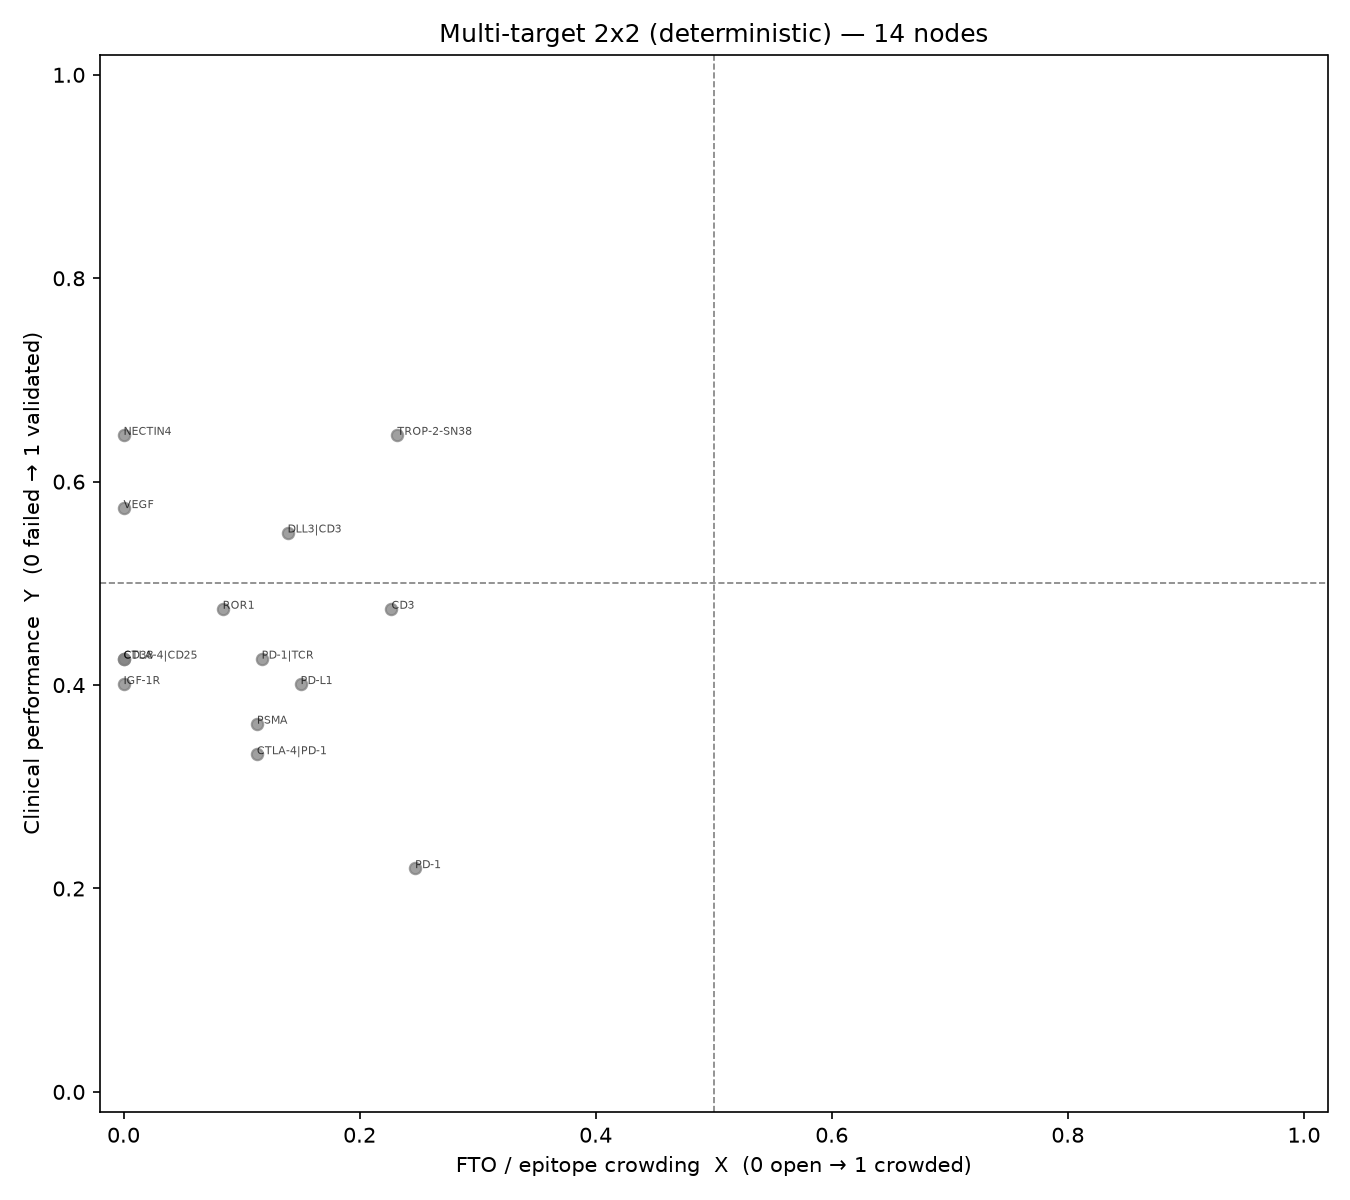

In [11]:
prostate_master, n_prostate_rows = analyze_tumor_cut(
    "prostate", "Prostate", TUMOR_INDICATION_TERMS["Prostate"], clin_scoped)
print(f"Prostate in-scope clinical rows: {n_prostate_rows:,} "
      f"({clin_scoped[clin_scoped['tumor_primary'] == 'Prostate']['target_harmonized'].nunique():,} distinct targets)")
line_counts = clin_scoped[clin_scoped["tumor_primary"] == "Prostate"]["m_line_of_therapy"].value_counts()
print(f"Line-of-therapy volume in Prostate: {dict(line_counts)}")

prostate_summary = summarize_cut(prostate_master, "prostate", "Prostate",
                                  os.path.join(RUNS_DIR, "prostate"))

for line in ("1L", "2L"):
    if line_counts.get(line, 0) >= MIN_LINE_ROWS:
        sub_master, n_sub = analyze_tumor_cut(
            f"prostate_{line.lower()}", "Prostate", TUMOR_INDICATION_TERMS["Prostate"],
            clin_scoped, line_filter=line)
        print(f"\\n-- Prostate {line} sub-cut ({n_sub} rows) --")
        summarize_cut(sub_master, f"prostate_{line.lower()}", f"Prostate {line}",
                      os.path.join(RUNS_DIR, f"prostate_{line.lower()}"))
    else:
        print(f"\\nProstate {line}: only {line_counts.get(line, 0)} rows (< {MIN_LINE_ROWS}) -- skipping sub-cut.")

## Entry 12: Systematic Sweep -- All Remaining Named Solid Tumor Types

1L/2L sub-cut tables/charts are kept out of the notebook body to control length (counts are still printed and exported to CSV) -- the main per-tumor cuts show full quadrant + watch-list detail and chart, exactly like the Pancreatic/Prostate runs above.

Running 17 remaining named solid tumor types, ranked by trial volume:
['NSCLC', 'Breast', 'Colorectal', 'Gastric_Esophageal', 'Lung_Other', 'HNSCC', 'Melanoma', 'Hepatocellular', 'Ovarian', 'Glioma_CNS', 'Bladder_Urothelial', 'SCLC', 'RCC', 'Sarcoma', 'Biliary_Cholangio', 'Cervical', 'Endometrial_Uterine']
[NSCLC] 1424 nodes, 50 placed on 2x2 -- TRUE WHITE SPACE=16 BATTLEGROUND=0 R&D TRAP=34 RED FLAGS=0 | watch-lists: IP-only=589 clinical-only=107
  Top TRUE WHITE SPACE: PD-1, PD-L1, TROP-2-DXD, VEGF, PD-1|VEGF
[NSCLC 1L] 1163 nodes, 6 placed on 2x2 -- TRUE WHITE SPACE=4 BATTLEGROUND=0 R&D TRAP=2 RED FLAGS=0 | watch-lists: IP-only=633 clinical-only=6
  Top TRUE WHITE SPACE: EGFR, EGFR|MET, PD-L1, PD-1|PD-L1
[NSCLC 2L] 1156 nodes, 5 placed on 2x2 -- TRUE WHITE SPACE=0 BATTLEGROUND=0 R&D TRAP=5 RED FLAGS=0 | watch-lists: IP-only=634 clinical-only=6
[Breast] 1288 nodes, 43 placed on 2x2 -- TRUE WHITE SPACE=13 BATTLEGROUND=0 R&D TRAP=30 RED FLAGS=0 | watch-lists: IP-only=596 clinical-only=

,n_targets
quadrant,
TRUE WHITE SPACE,16
BATTLEGROUND,0
R&D TRAP,34
RED FLAGS,0
UNRESOLVED,1374


,target_harmonized,clinical_performance_Y,clinical_label,n_trials,epitope_crowding_X,patents_grounded,blocking_assignee,key_patent
1000,PD-1,1.000,VALIDATED,562,0.259,10,"ABALYTICS ONCOLOGY, INC.",WO2025240670A2
1112,PD-L1,1.000,VALIDATED,195,0.223,12,"EXELIXIS, INC.",WO2026030408A1
1326,TROP-2-DXD,1.000,VALIDATED,15,0.247,10,"ACTINIUM PHARMACEUTICALS, INC.",WO2026055611A1
1376,VEGF,1.000,VALIDATED,186,0.000,1,"SUZHOU NEOLOGICS BIOSCIENCE CO., LTD.",WO2025195479A1
1100,PD-1|VEGF,0.999,VALIDATED,31,0.042,2,"PARAGON THERAPEUTICS, INC.",WO2026064650A1
690,HER2-DXD,0.994,VALIDATED,9,0.130,4,FUDAN UNIVERSITY,WO2024001844A1
543,EGFR|MET,0.961,VALIDATED,35,0.382,30,"CHIA TAI TIANQING PHARMACEUTICAL GROUP CO., LTD.",WO2026086844A1
707,HER2|HER3,0.858,VALIDATED,4,0.097,5,"SYSTIMMUNE, INC.",WO2025117871A1
512,EGFR,0.750,VALIDATED,149,0.206,9,"SHANGHAI RUOTUO BIOSCIENCES CO., LTD.",WO2026108369A1
1077,PD-1|PD-L1,0.750,VALIDATED,129,0.181,6,BIOTHEUS INC.,WO2025185733A1


,target_harmonized,clinical_performance_Y,clinical_label,n_trials,epitope_crowding_X,patents_grounded,blocking_assignee,key_patent
1008,PD-1-MAYTANSINOID,0.475,CONTESTED,1,0.000,1,"GENEQUANTUM HEALTHCARE (SUZHOU) CO., LTD.",WO2024213091A1
1318,TROP-2,0.475,CONTESTED,9,0.042,2,AGENCY FOR SCIENCE,WO2025010028A1
1036,PD-1|CD40,0.475,CONTESTED,4,0.000,1,"BIOCYTOGEN PHARMACEUTICALS (BEIJING) CO., LTD",WO2022078357A1
1184,PTK7-AURISTATIN,0.475,CONTESTED,2,0.000,1,"SICHUAN KELUN-BIOTECH BIOPHARMACEUTICAL CO., LTD.",WO2024078586A1
661,GPC3,0.475,CONTESTED,1,0.097,5,"THE UNITED STATES OF AMERICA, AS REPRESENTED BY THE SECRETARY",WO2025207909A1
91,B7-H3|CD3,0.475,CONTESTED,1,0.000,1,DEUTSCHES KREBSFORSCHUNGSZENTRUM STIFTUNG DES ÖFFENTLICHEN RECHTS,WO2021099347A1
1060,PD-1|HER2,0.475,CONTESTED,7,0.000,1,"BEIJING HANMI PHARMACEUTICAL CO., LTD.",WO2019155408A1
1097,PD-1|TIM-3,0.450,CONTESTED,2,0.117,7,ASTRAZENECA UK LIMITED,WO2025088496A1
886,MESOTHELIN,0.450,CONTESTED,7,0.000,1,FRED HUTCHINSON CANCER CENTER,WO2021207242A2
251,CD3,0.426,CONTESTED,2,0.227,20,"ADIMAB, LLC",WO2026006458A1


,target_harmonized,epitope_crowding_X,patents_grounded,blocking_assignee,key_patent
4,5T4-MMAE,0.0,1,"SALUBRIS BIOTHERAPEUTICS, INC.",WO2024197151A2
5,5T4-MMAF,0.0,1,"SALUBRIS BIOTHERAPEUTICS, INC.",WO2024197151A2
31,ALK|VEGF,0.0,1,"KINTOR PHARMACEUTICAL (GUANGDONG) CO., LTD.",WO2023030433A1
33,ALPP|CD3,0.0,1,"PROMAB BIOTECHNOLOGIES, INC.",WO2021154534A1
43,APLP2|HER2-DM1,0.0,1,"REGENERON PHARMACEUTICALS, INC.",WO2019212965A1
44,APLP2|HER2-DM4,0.0,1,"REGENERON PHARMACEUTICALS, INC.",WO2019212965A1
58,AXL|PD-L1-DOXORUBICIN,0.0,1,CELON PHARMA S.A.,WO2025080151A1
59,AXL|PD-L1-MMAE,0.0,1,CELON PHARMA S.A.,WO2025080151A1
60,AXL|PD-L1-MMAF,0.0,1,CELON PHARMA S.A.,WO2025080151A1
61,AXL|PD-L1-PBD,0.0,1,CELON PHARMA S.A.,WO2025080151A1


...

,n_targets
quadrant,
TRUE WHITE SPACE,1
BATTLEGROUND,0
R&D TRAP,4
RED FLAGS,0
UNRESOLVED,1150


,target_harmonized,clinical_performance_Y,clinical_label,n_trials,epitope_crowding_X,patents_grounded,blocking_assignee,key_patent
600,HER2,0.756,VALIDATED,5,0.139,10,ZYMEWORKS BC INC.,WO2023141714A1


,target_harmonized,clinical_performance_Y,clinical_label,n_trials,epitope_crowding_X,patents_grounded,blocking_assignee,key_patent
904,PD-1|PD-L1,0.426,CONTESTED,4,0.108,6,BIOTHEUS INC.,WO2025185733A1
911,PD-L1,0.354,FAILED / CONTESTED (late),7,0.150,12,"EXELIXIS, INC.",WO2026030408A1
874,PD-1,0.256,FAILED / CONTESTED (late),33,0.139,10,"ABALYTICS ONCOLOGY, INC.",WO2025240670A2
1128,VEGF,0.187,FAILED / CONTESTED (late),9,0.000,1,"SUZHOU NEOLOGICS BIOSCIENCE CO., LTD.",WO2025195479A1


,target_harmonized,epitope_crowding_X,patents_grounded,blocking_assignee,key_patent
2,5T4-MMAE,0.0,1,"SALUBRIS BIOTHERAPEUTICS, INC.",WO2024197151A2
3,5T4-MMAF,0.0,1,"SALUBRIS BIOTHERAPEUTICS, INC.",WO2024197151A2
21,ALK|VEGF,0.0,1,"KINTOR PHARMACEUTICAL (GUANGDONG) CO., LTD.",WO2023030433A1
23,ALPP|CD3,0.0,1,"PROMAB BIOTECHNOLOGIES, INC.",WO2021154534A1
33,APLP2|HER2-DM1,0.0,1,"REGENERON PHARMACEUTICALS, INC.",WO2019212965A1
34,APLP2|HER2-DM4,0.0,1,"REGENERON PHARMACEUTICALS, INC.",WO2019212965A1
45,AXL|PD-L1-DOXORUBICIN,0.0,1,CELON PHARMA S.A.,WO2025080151A1
46,AXL|PD-L1-MMAE,0.0,1,CELON PHARMA S.A.,WO2025080151A1
47,AXL|PD-L1-MMAF,0.0,1,CELON PHARMA S.A.,WO2025080151A1
48,AXL|PD-L1-PBD,0.0,1,CELON PHARMA S.A.,WO2025080151A1


,target_harmonized,clinical_performance_Y,clinical_label,n_trials
902,PD-1|LAG-3|PD-L1|TIM-3,0.646,VALIDATED,1
554,FOLR1|VEGF,0.426,CONTESTED,1
887,PD-1|AXL,0.426,CONTESTED,1
889,PD-1|CD137|PD-L1,0.426,CONTESTED,1


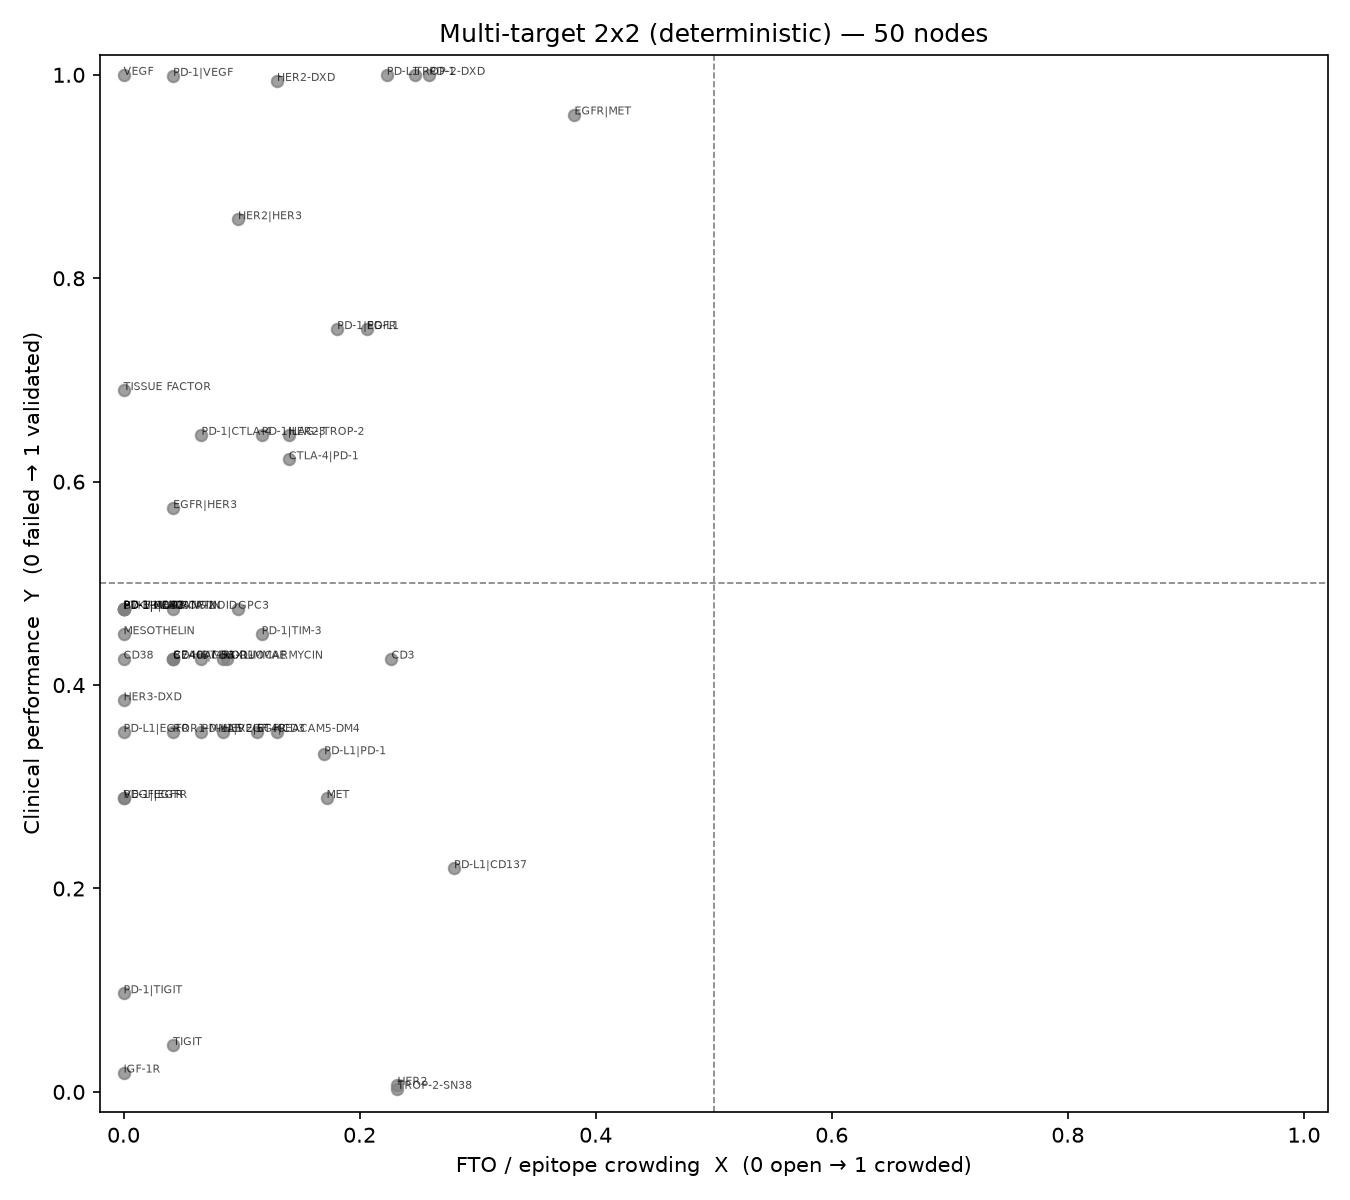

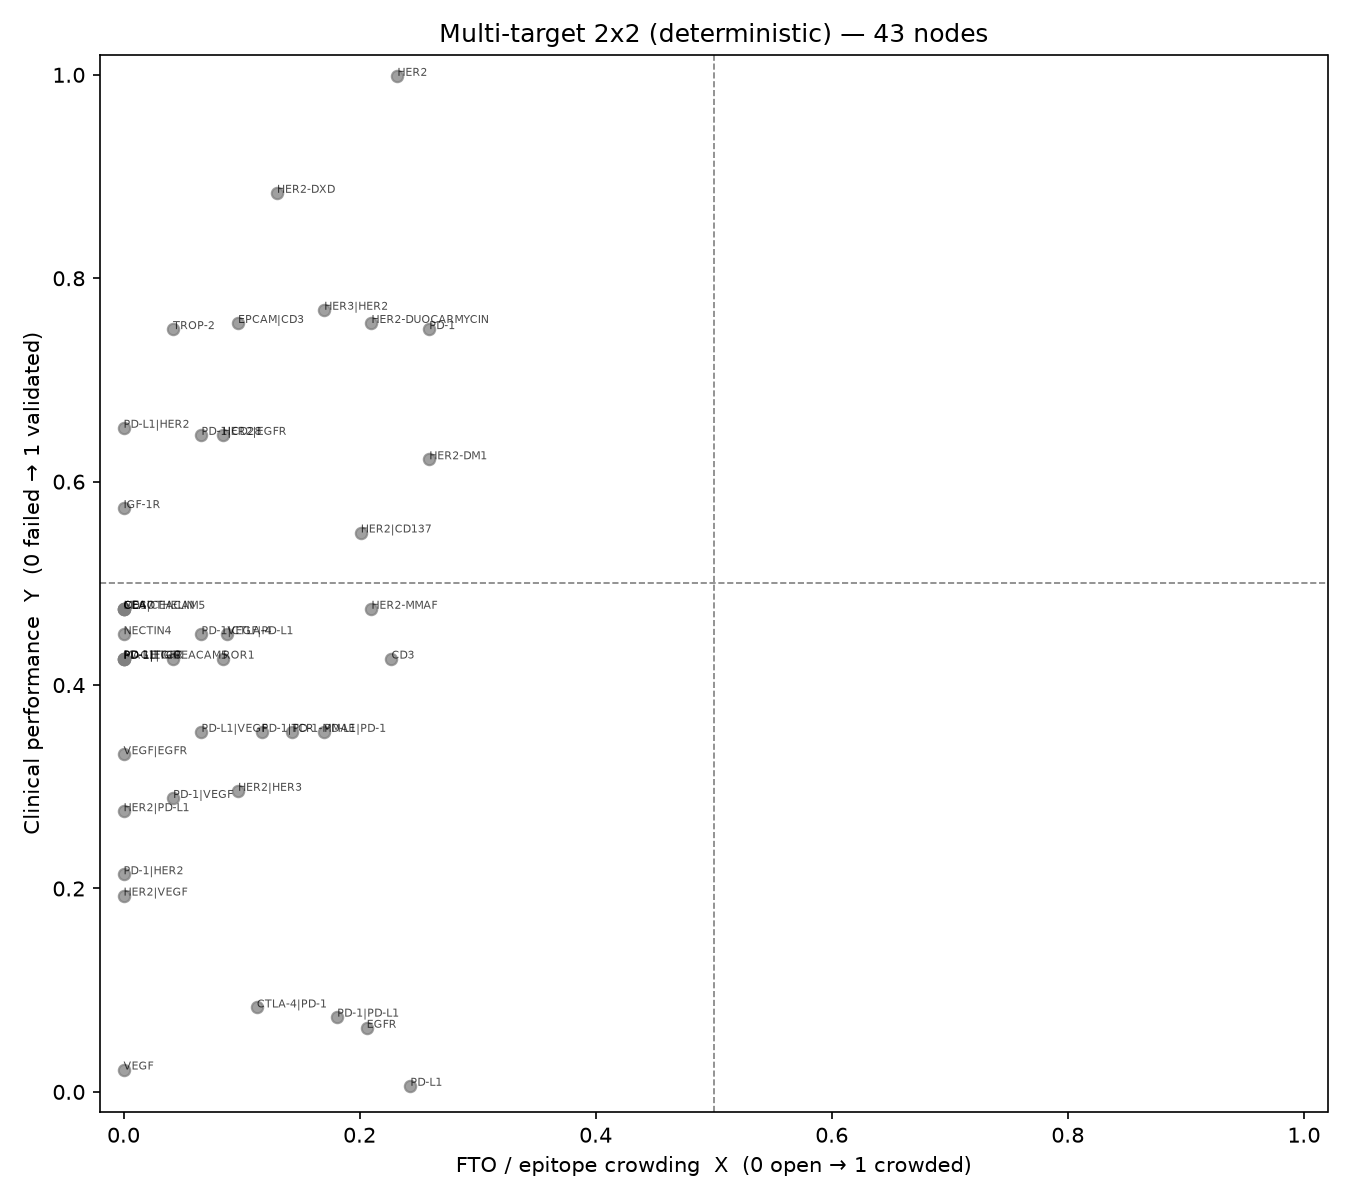

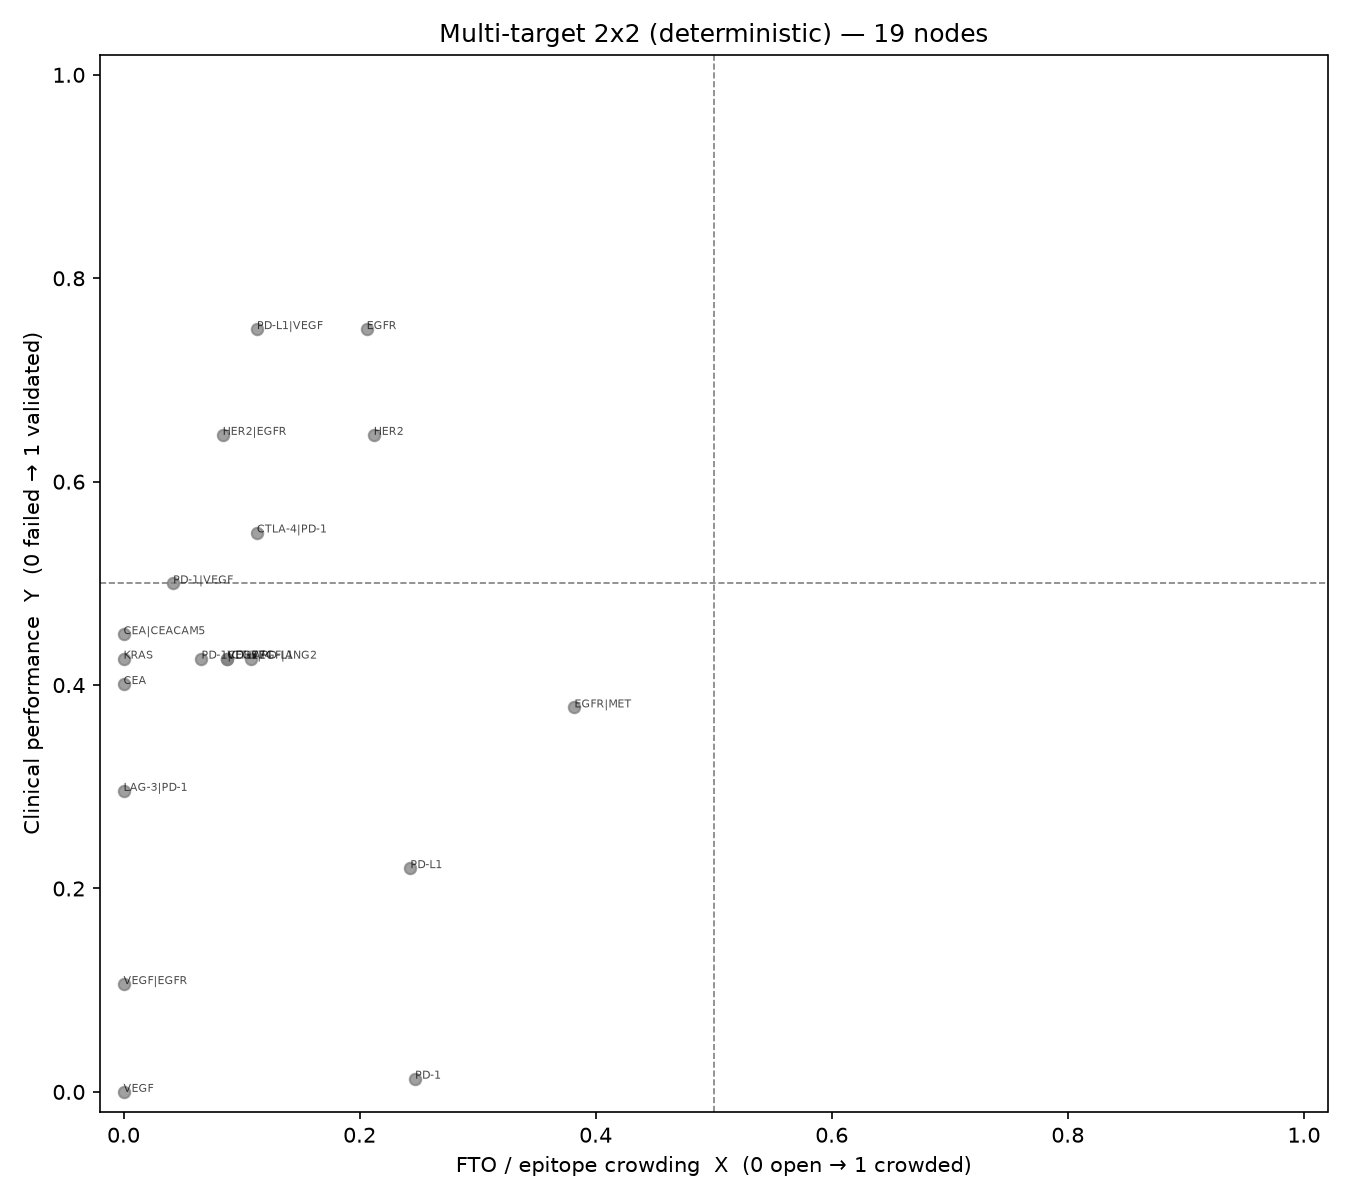

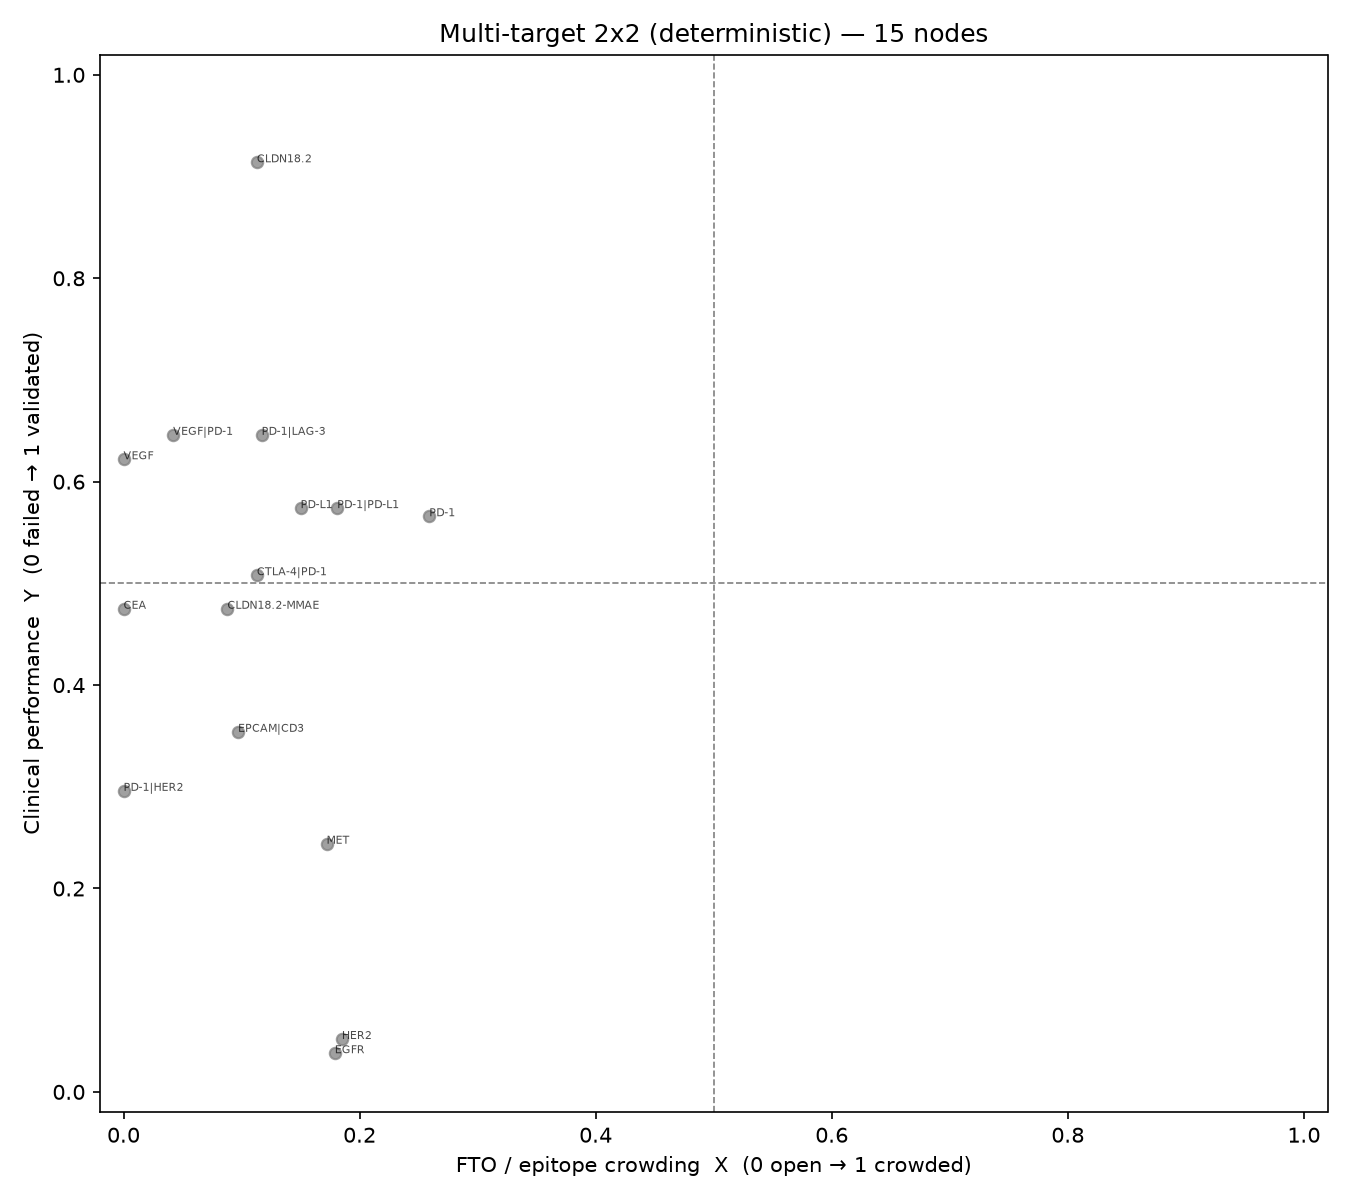

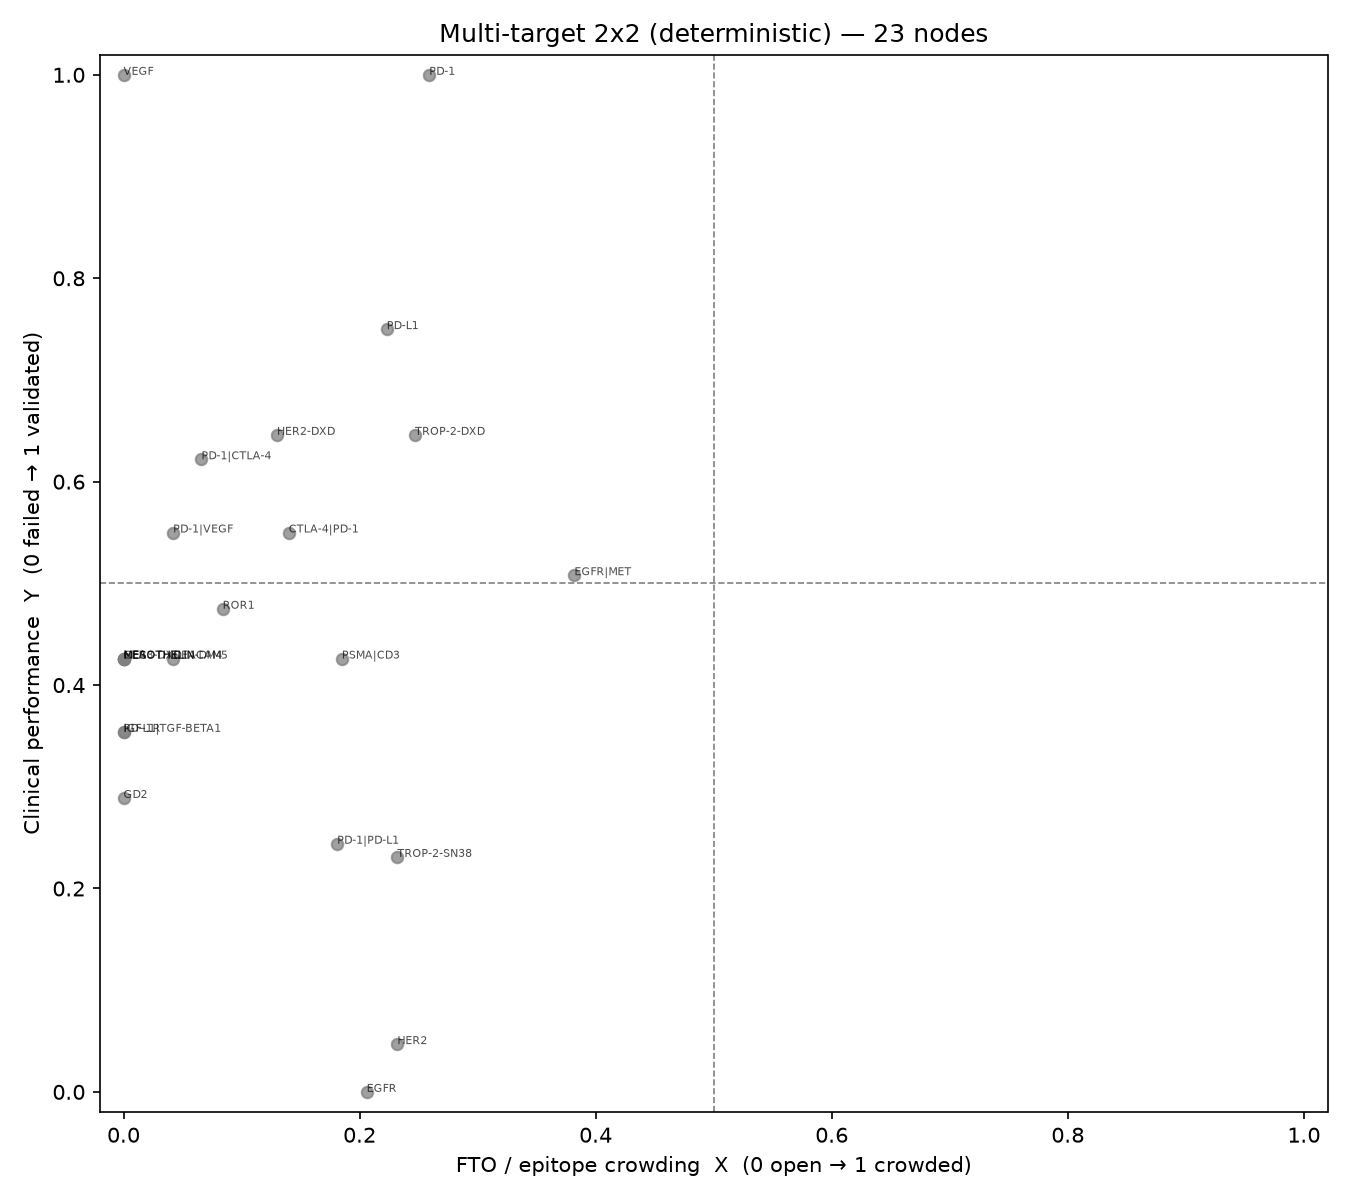

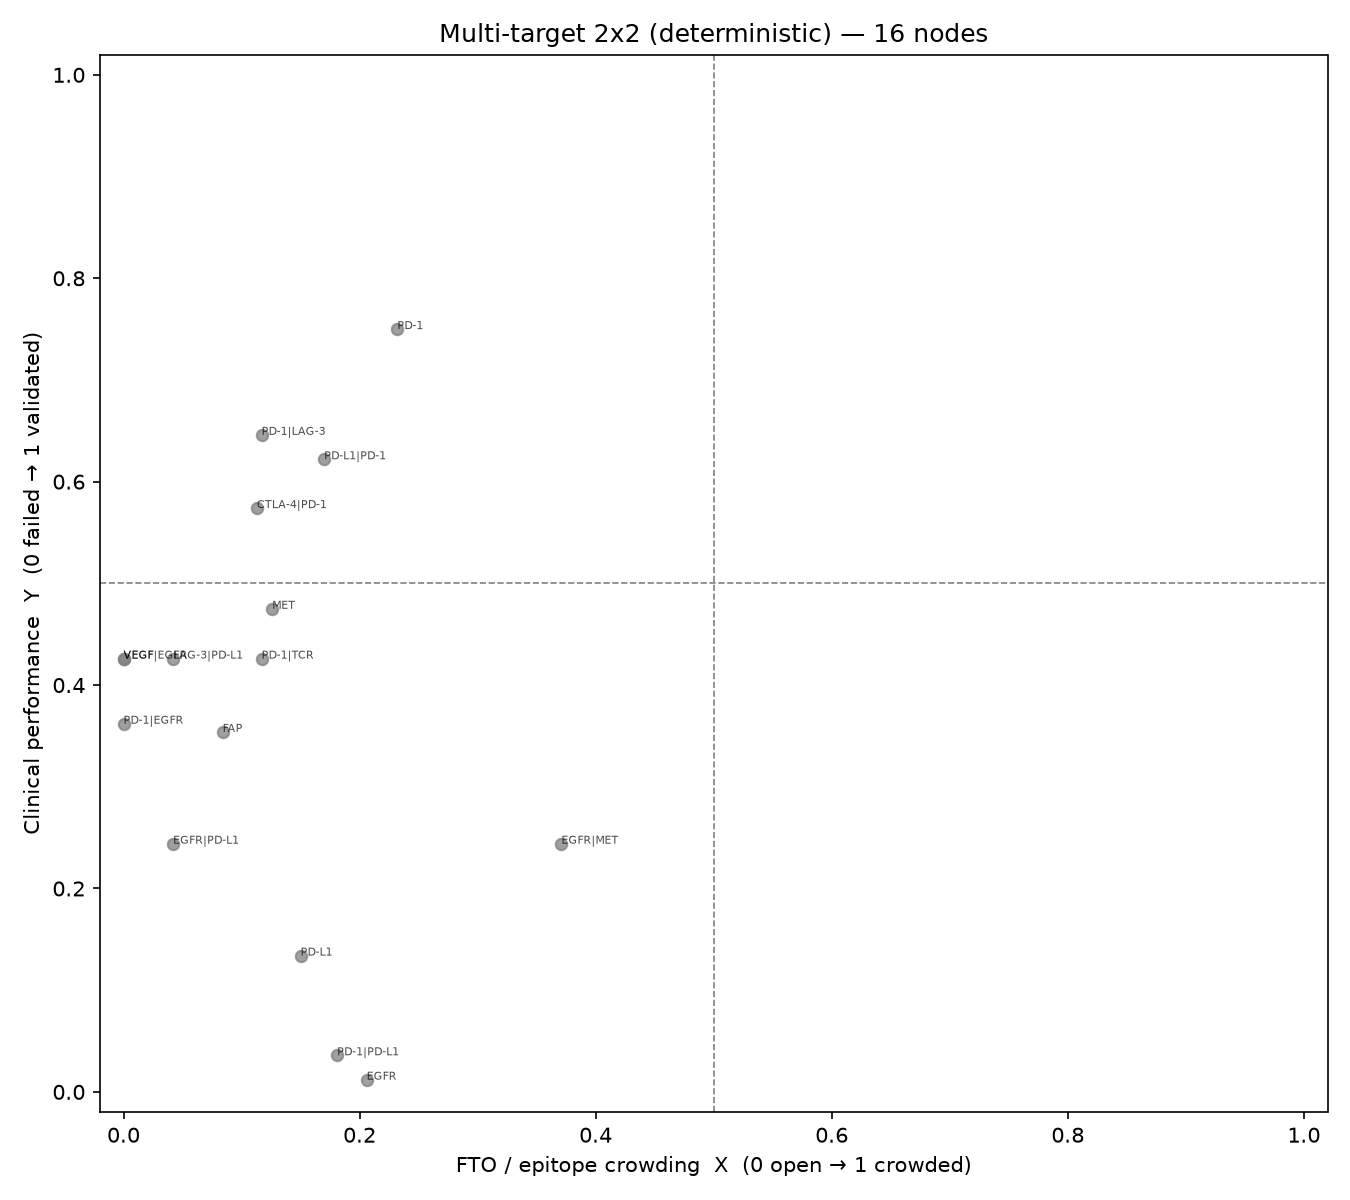

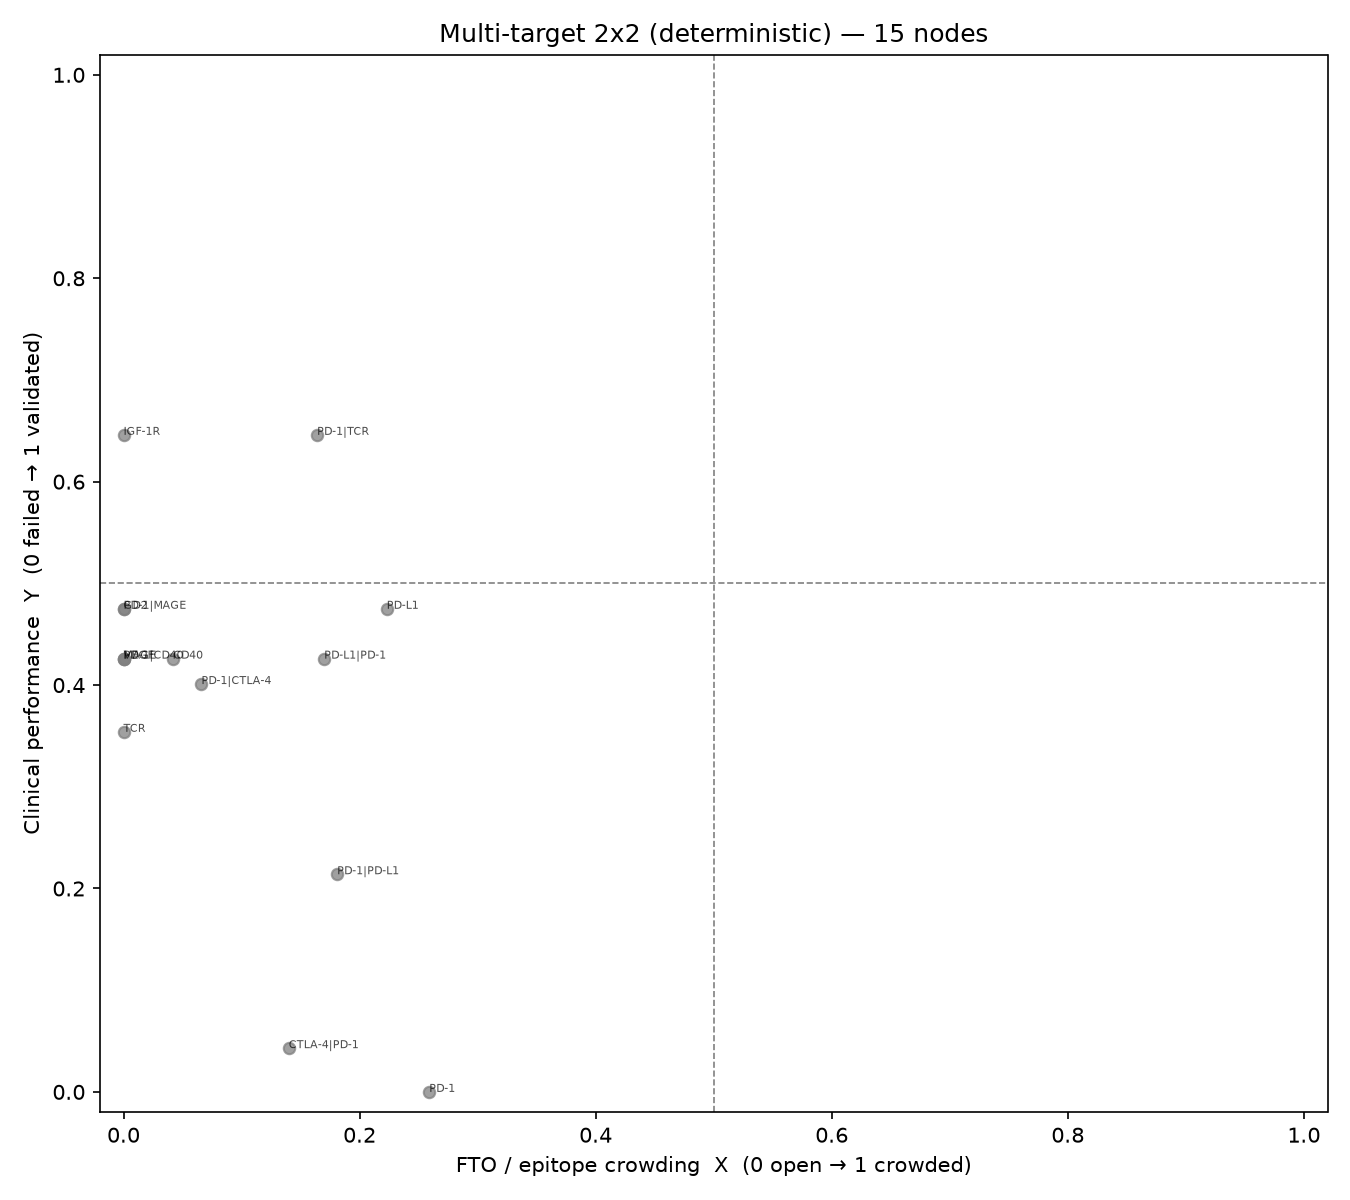

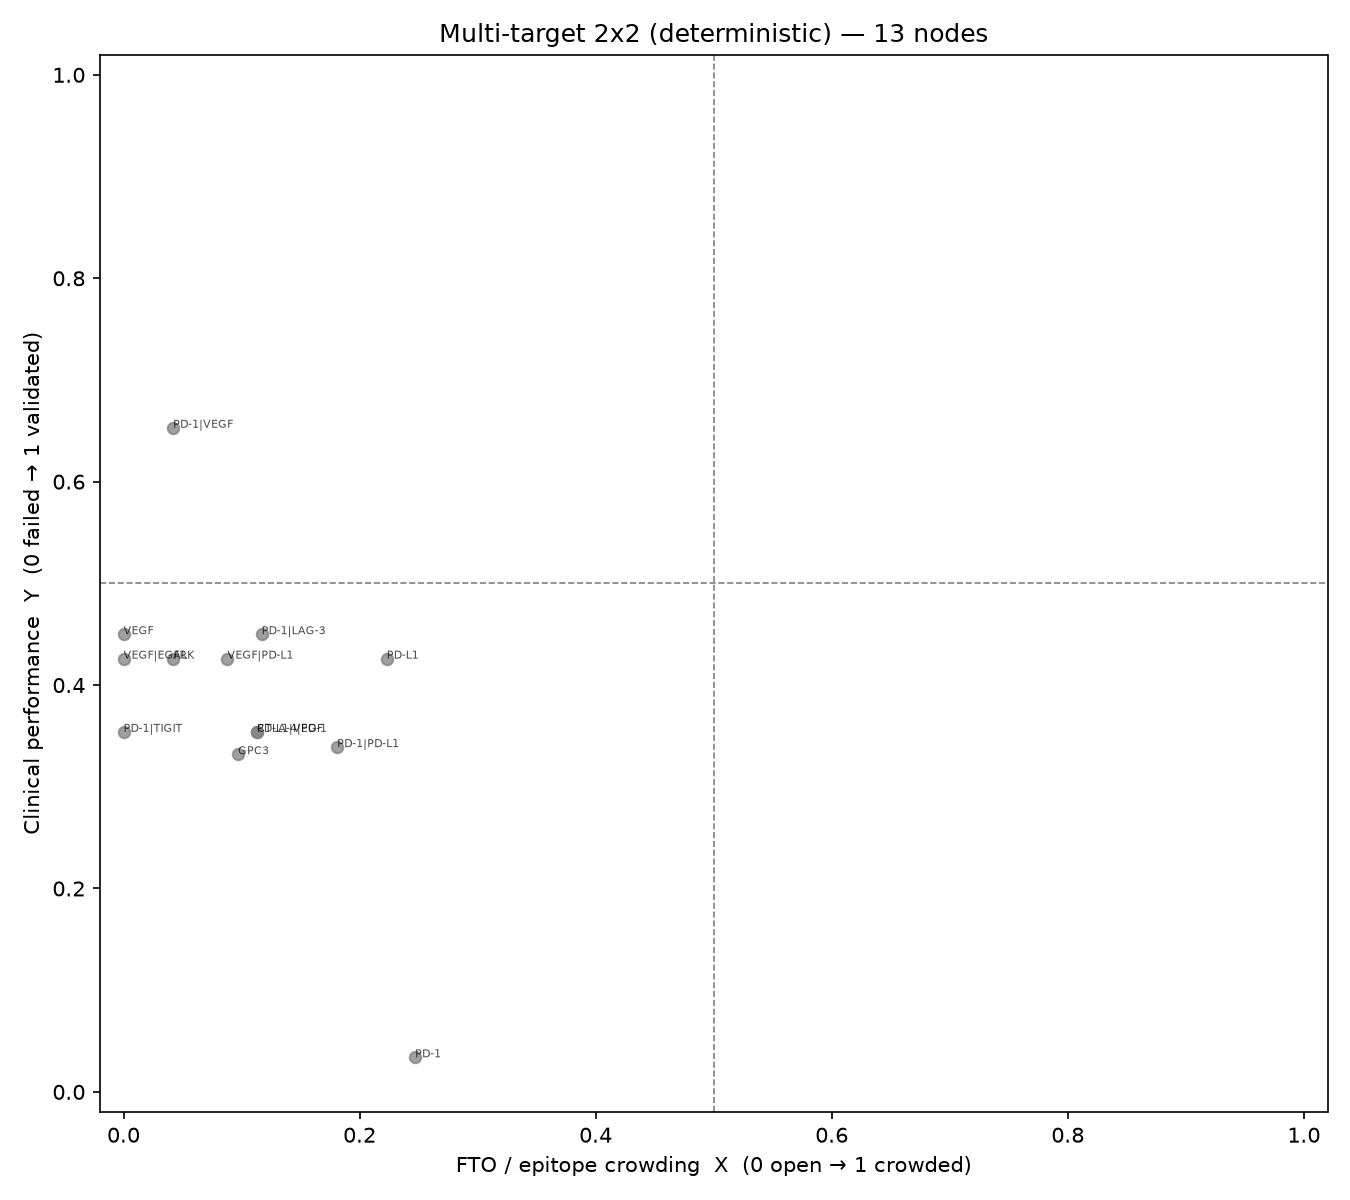

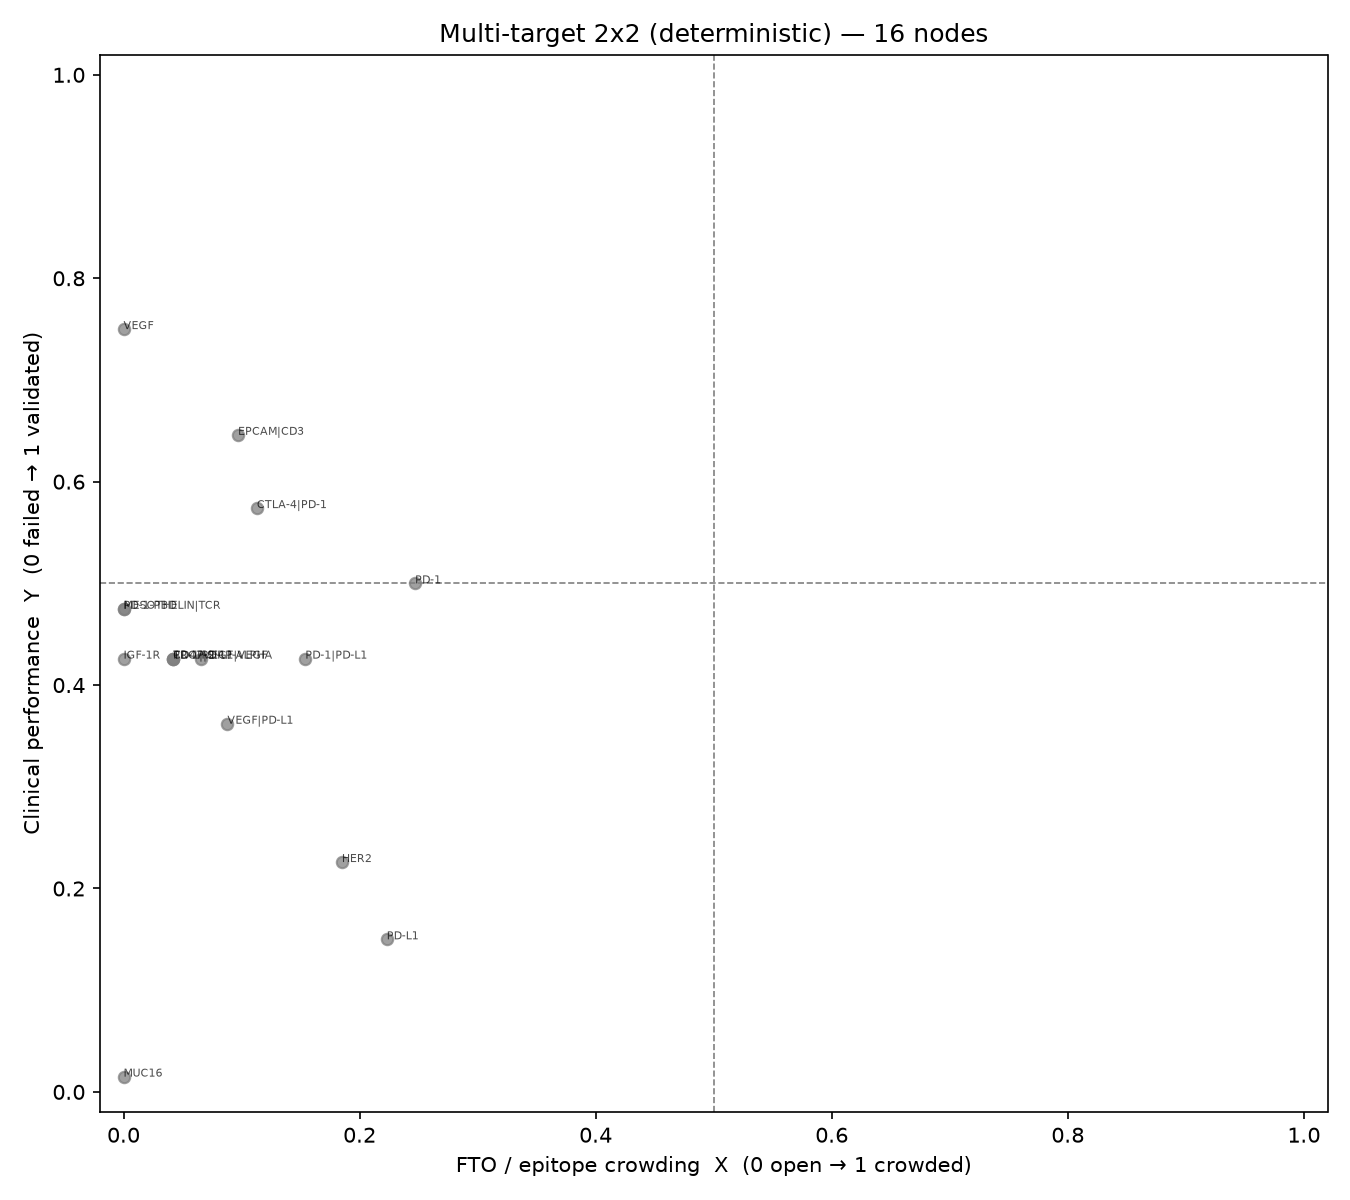

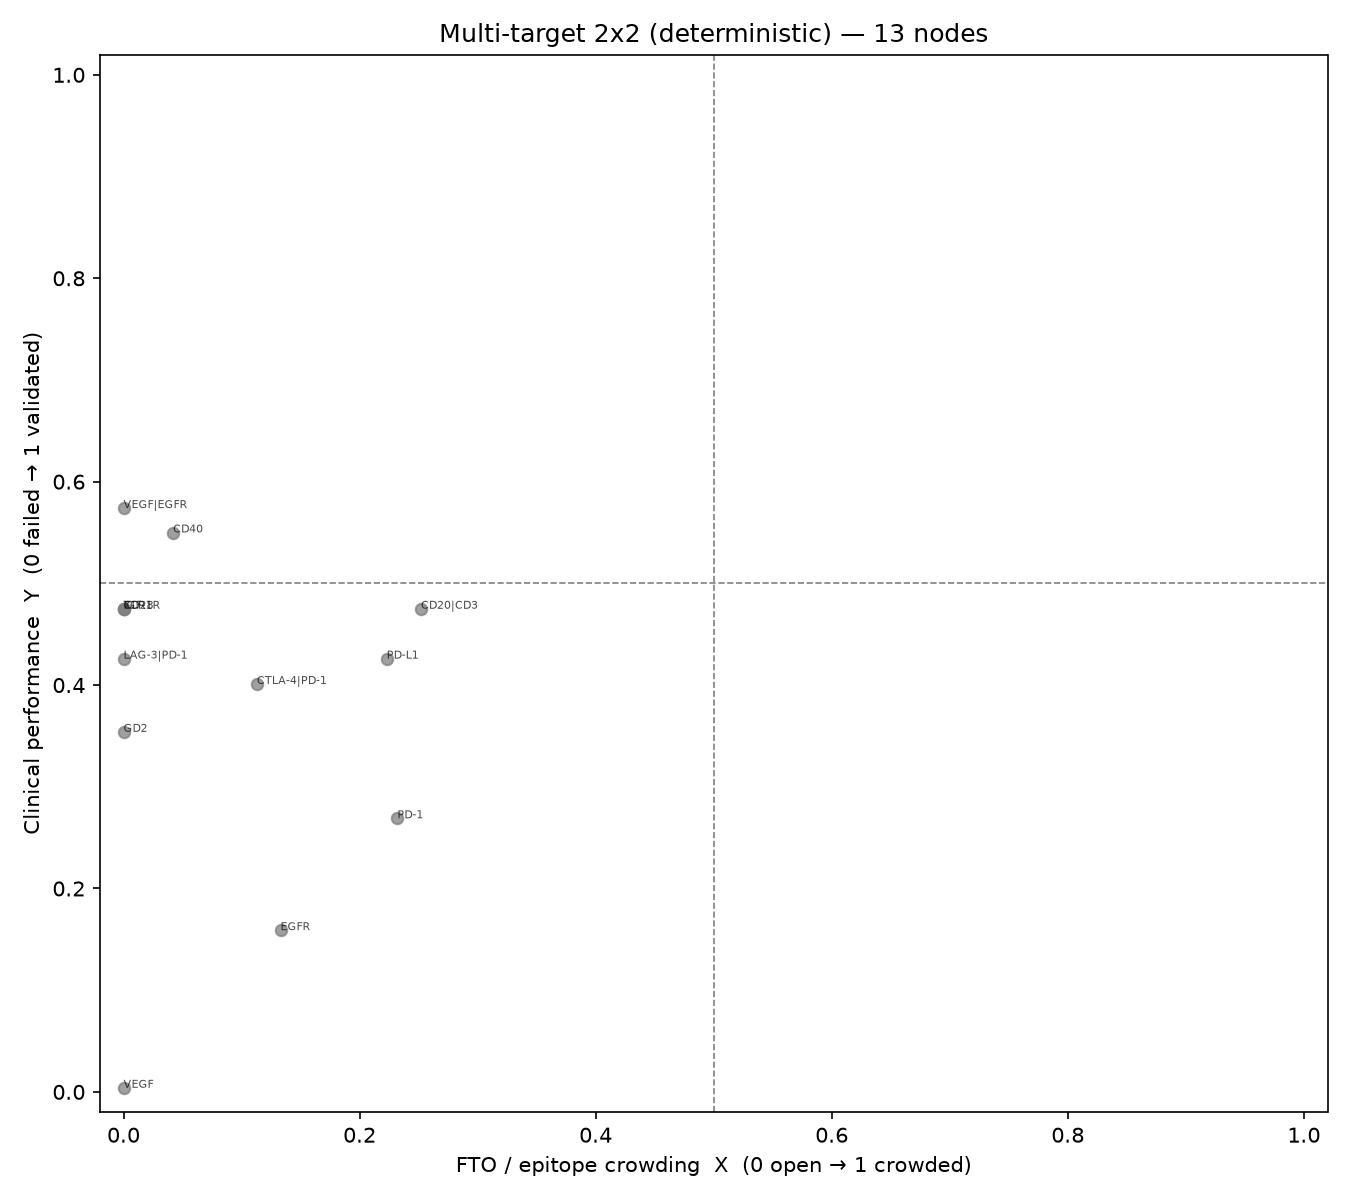

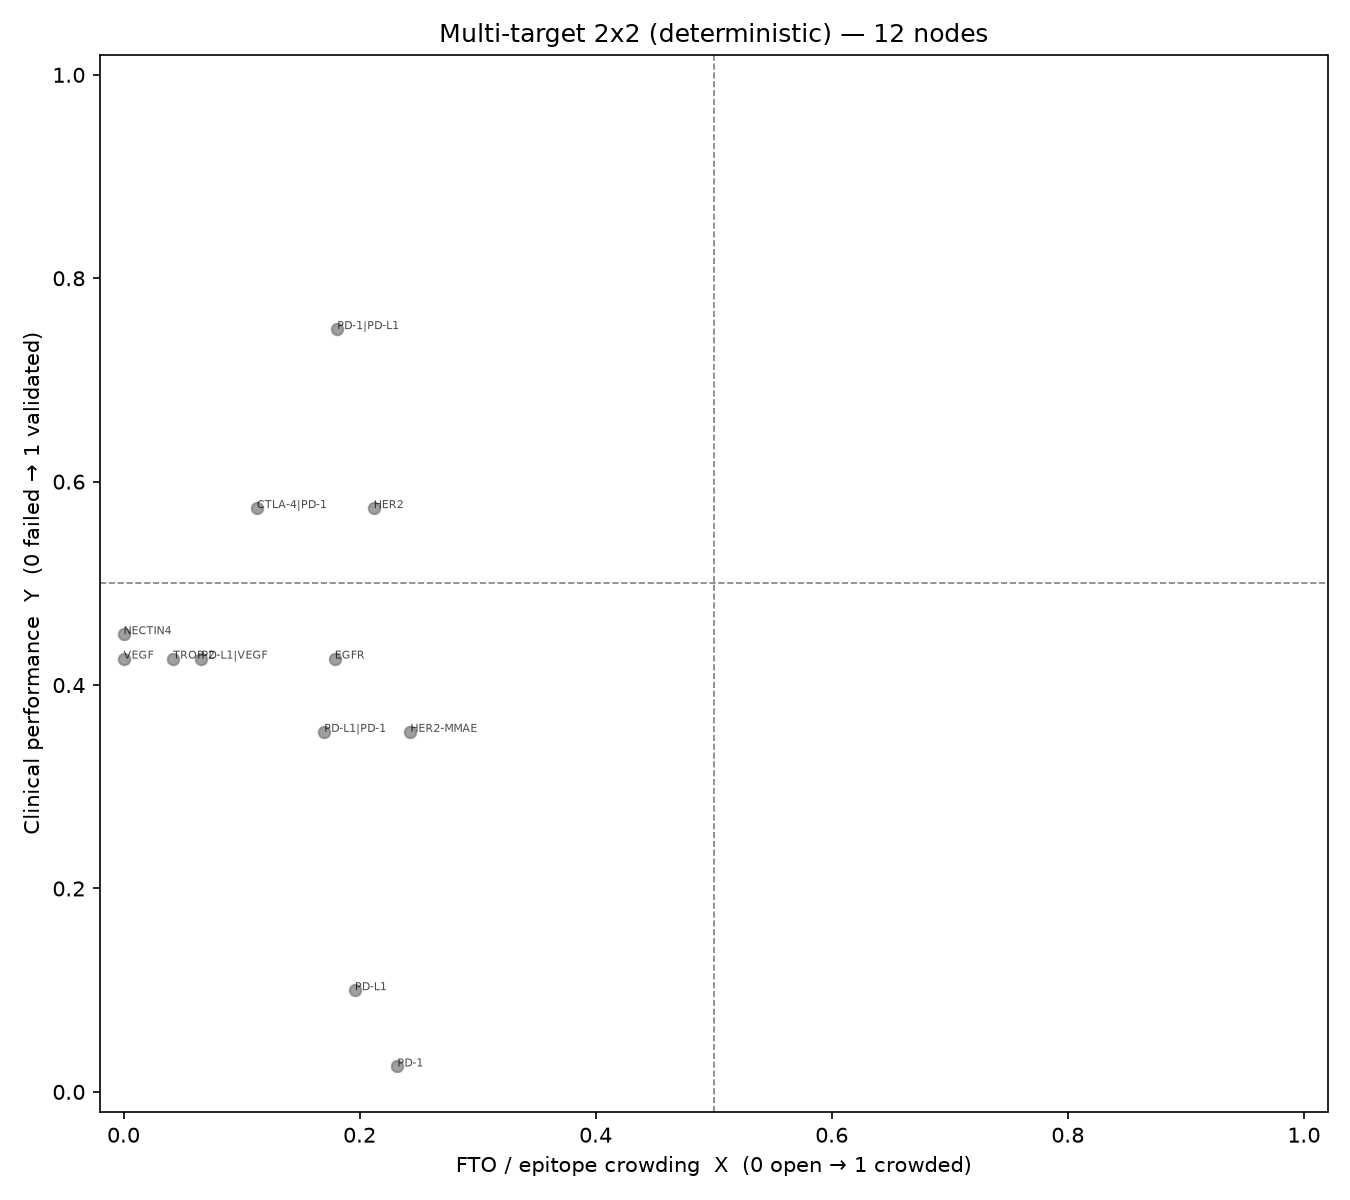

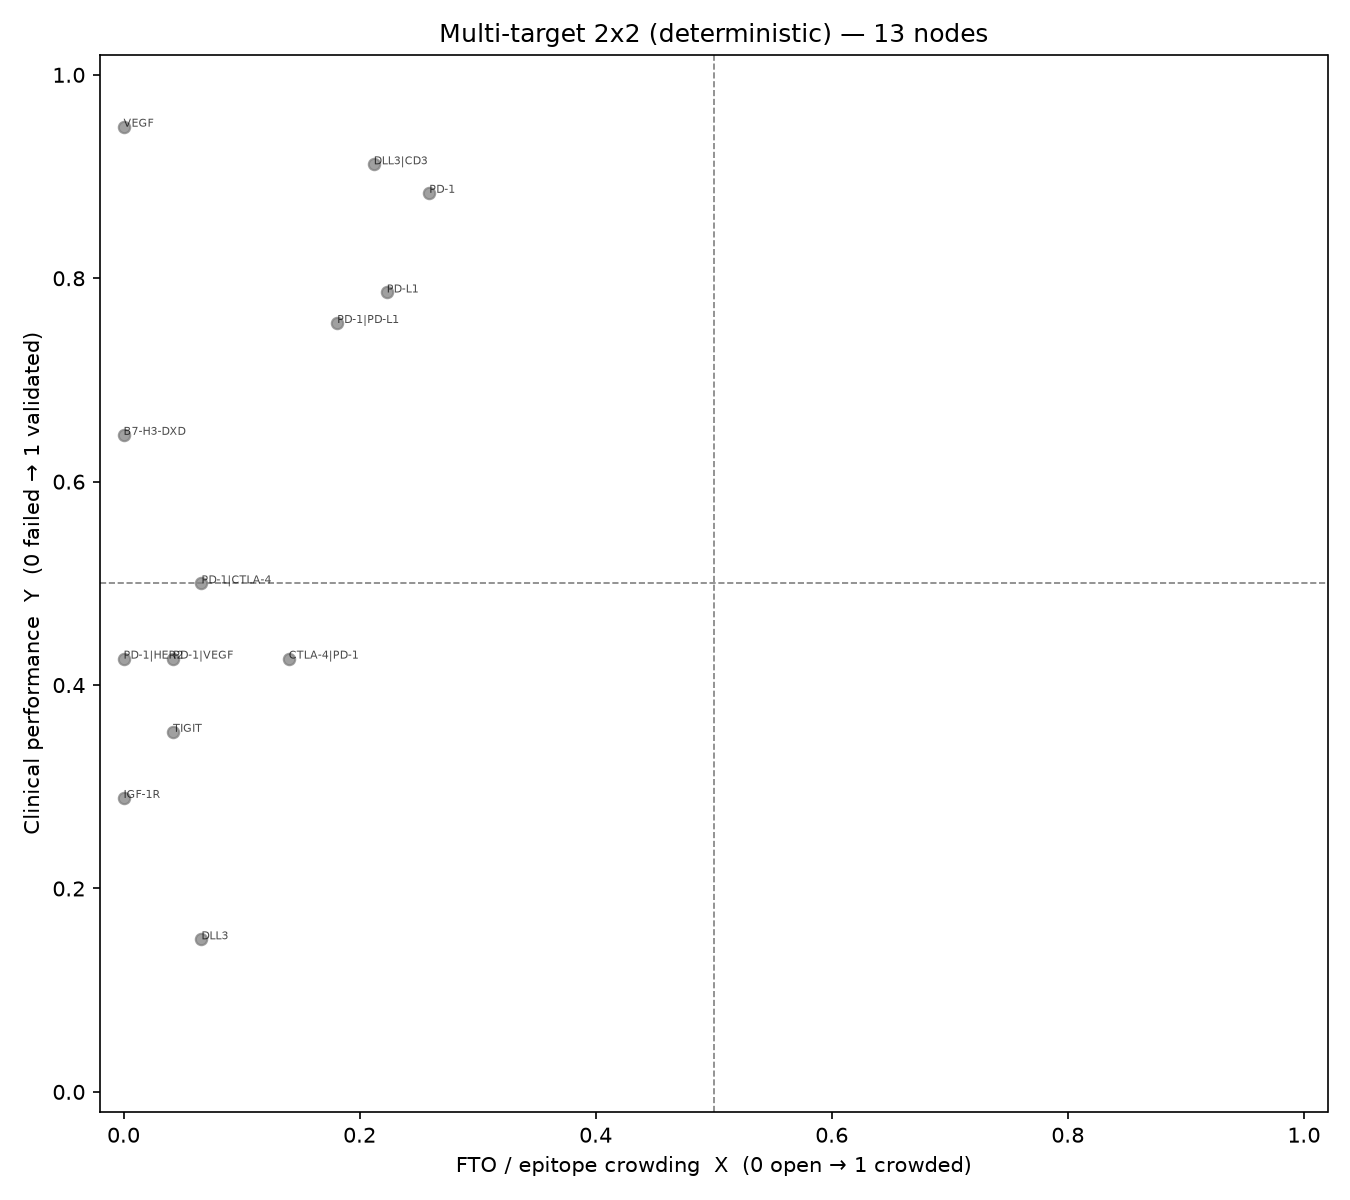

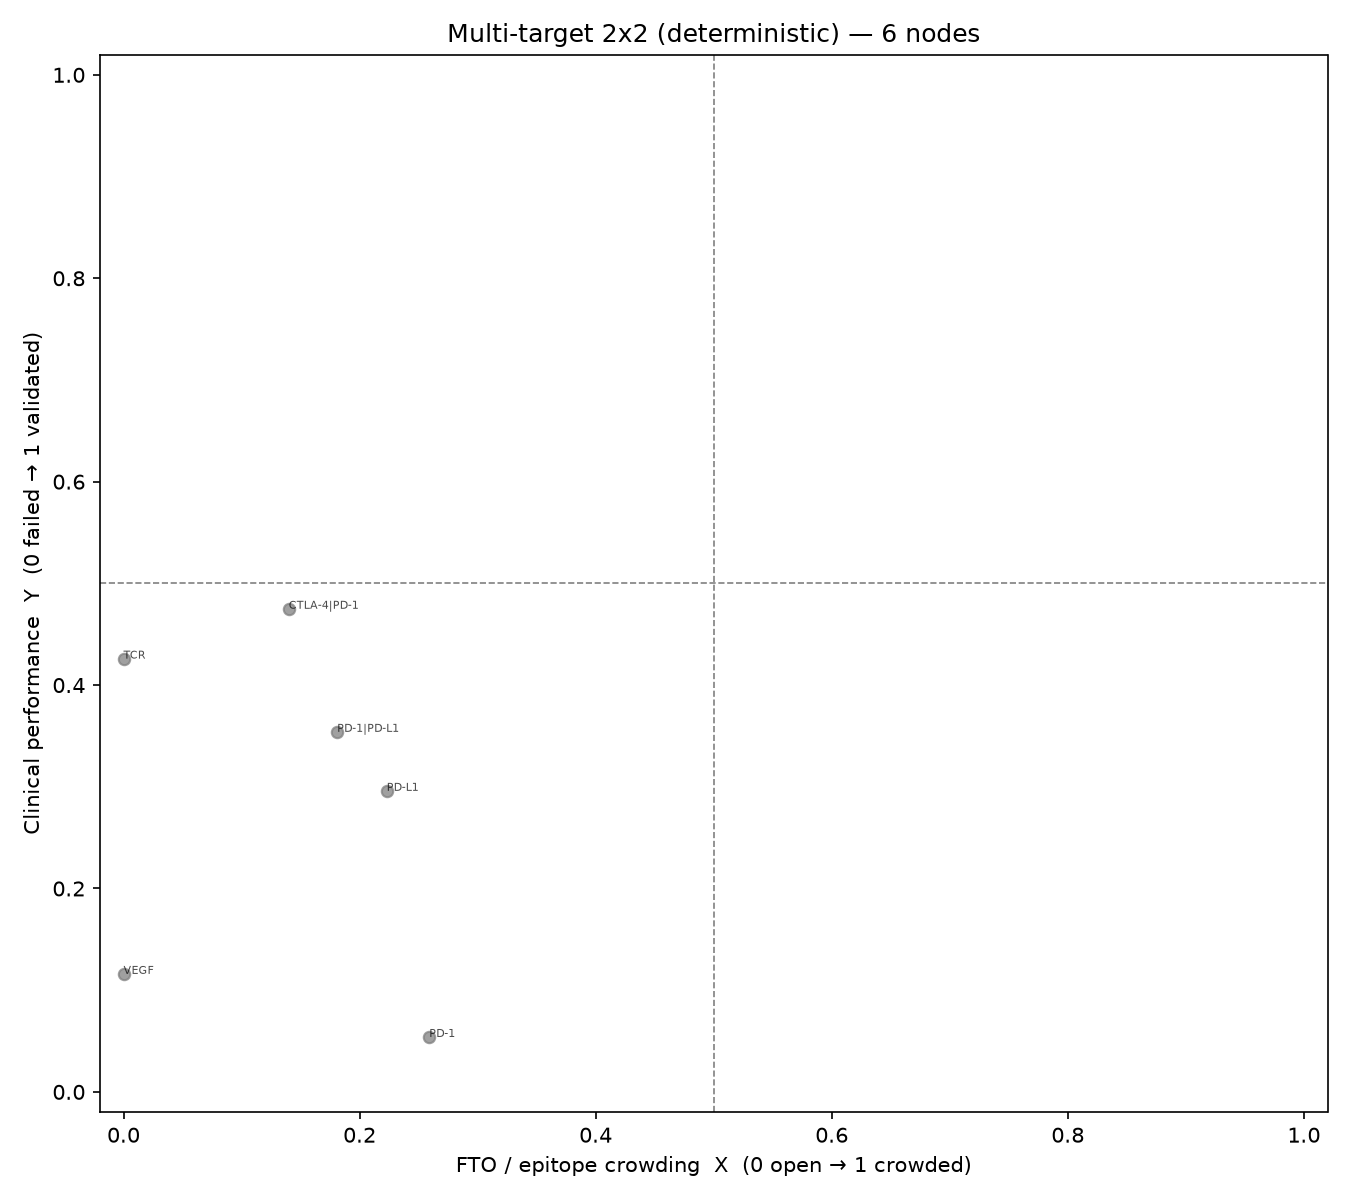

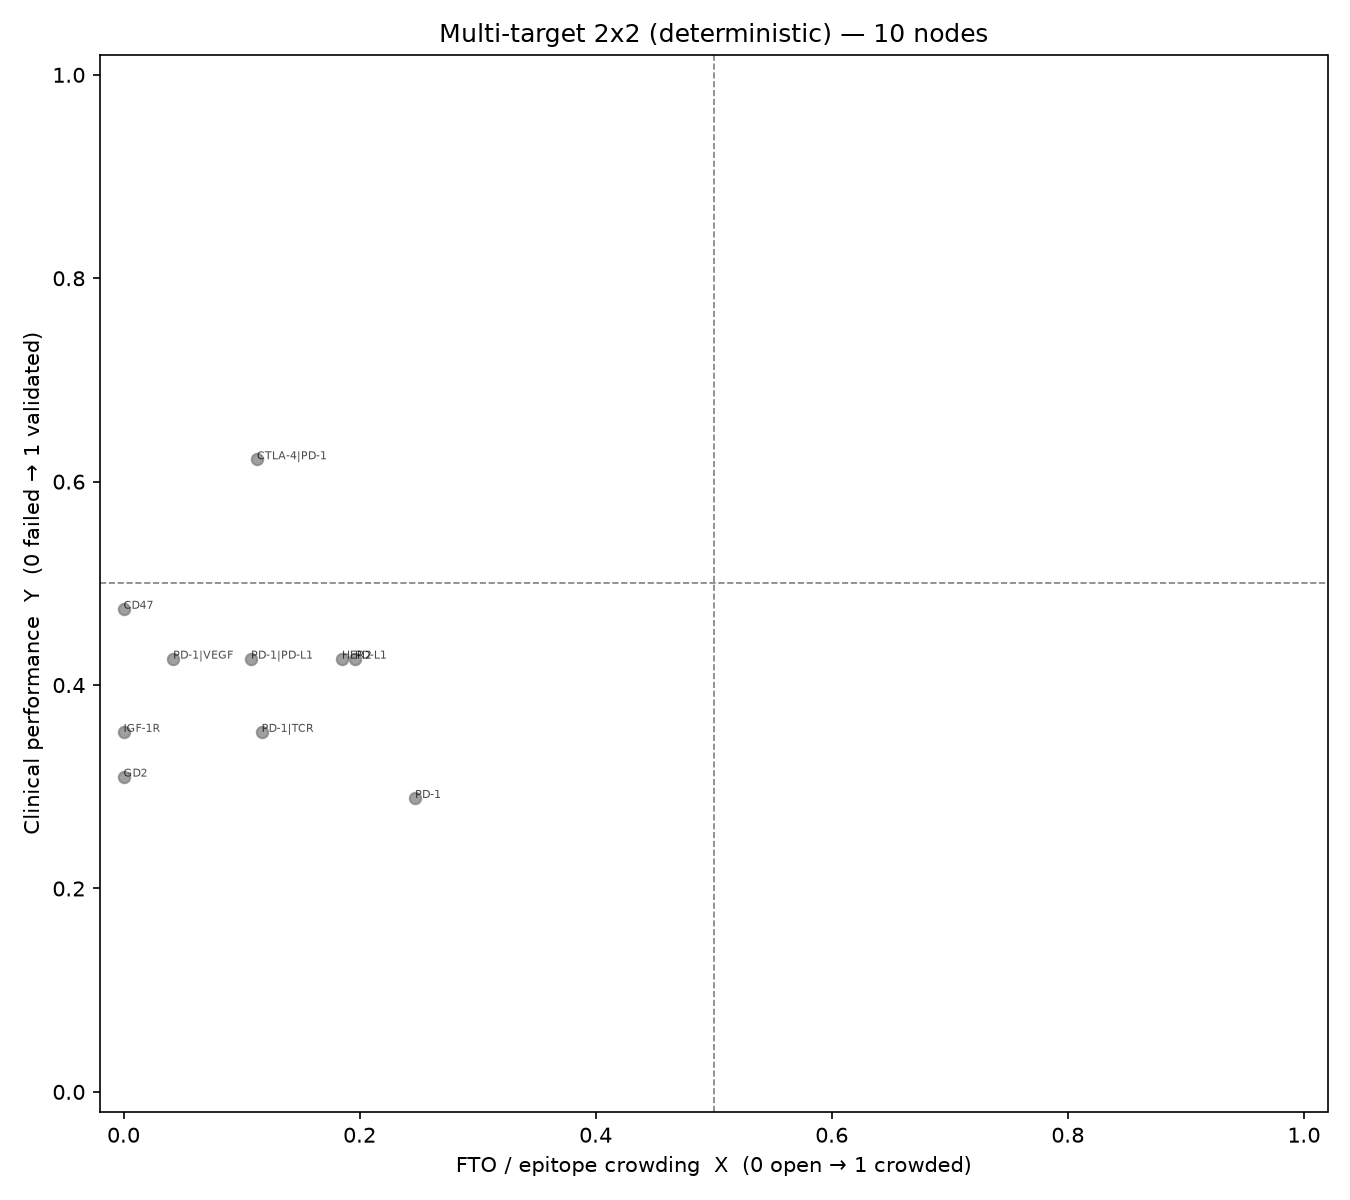

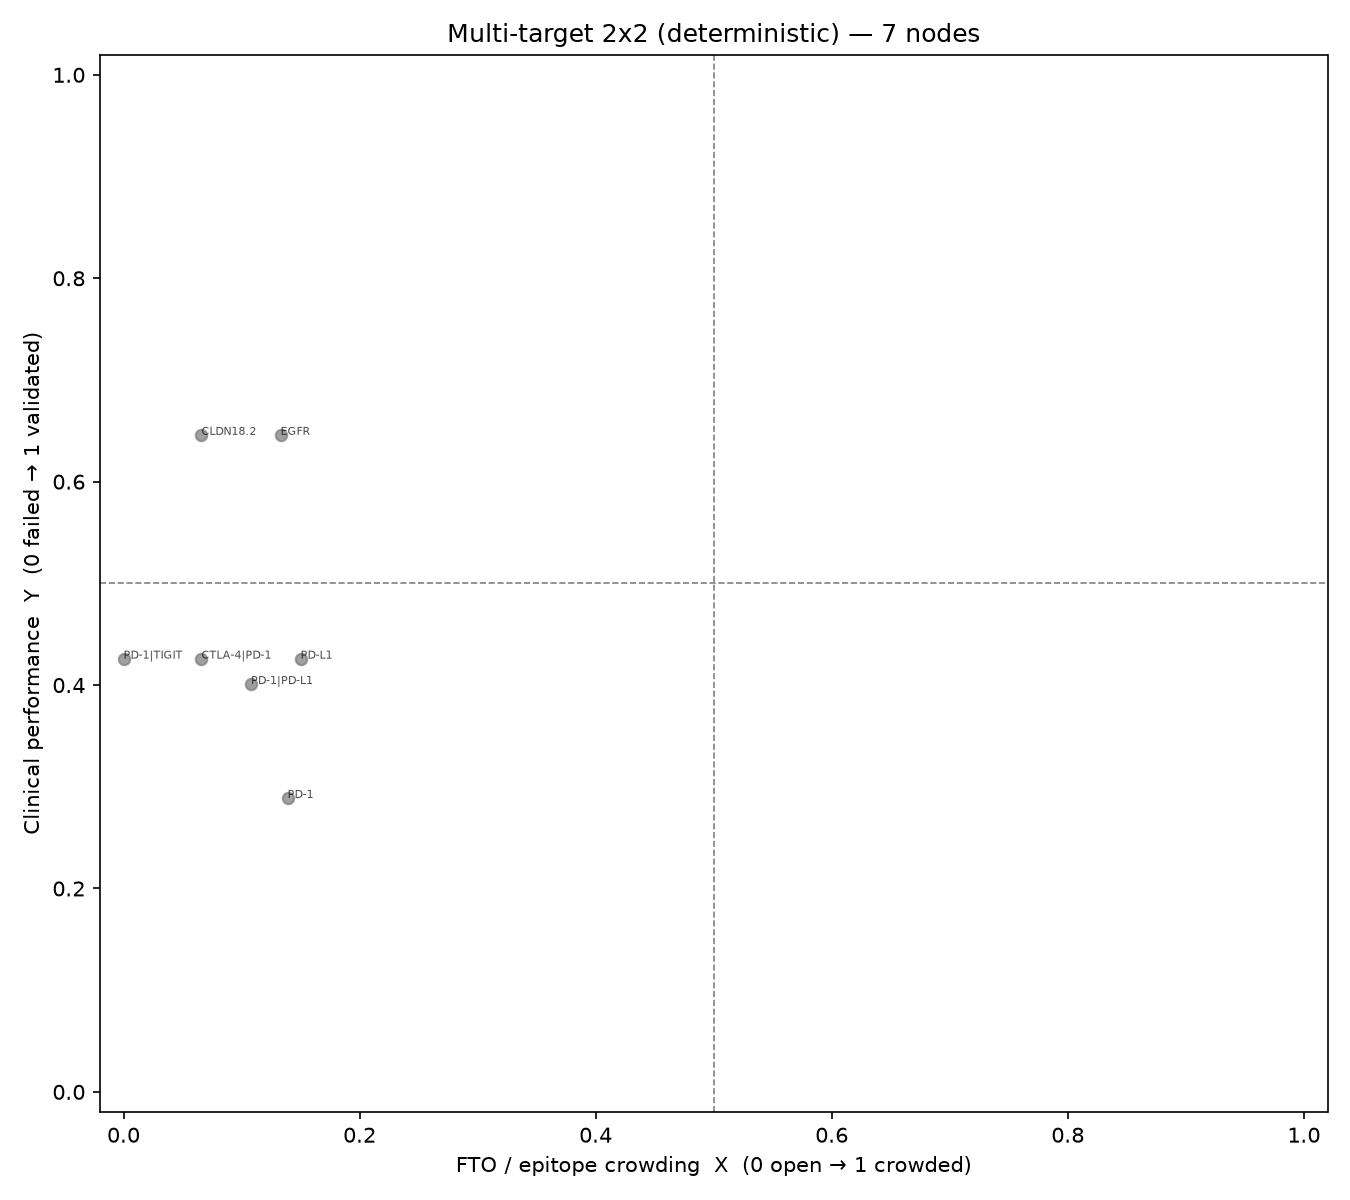

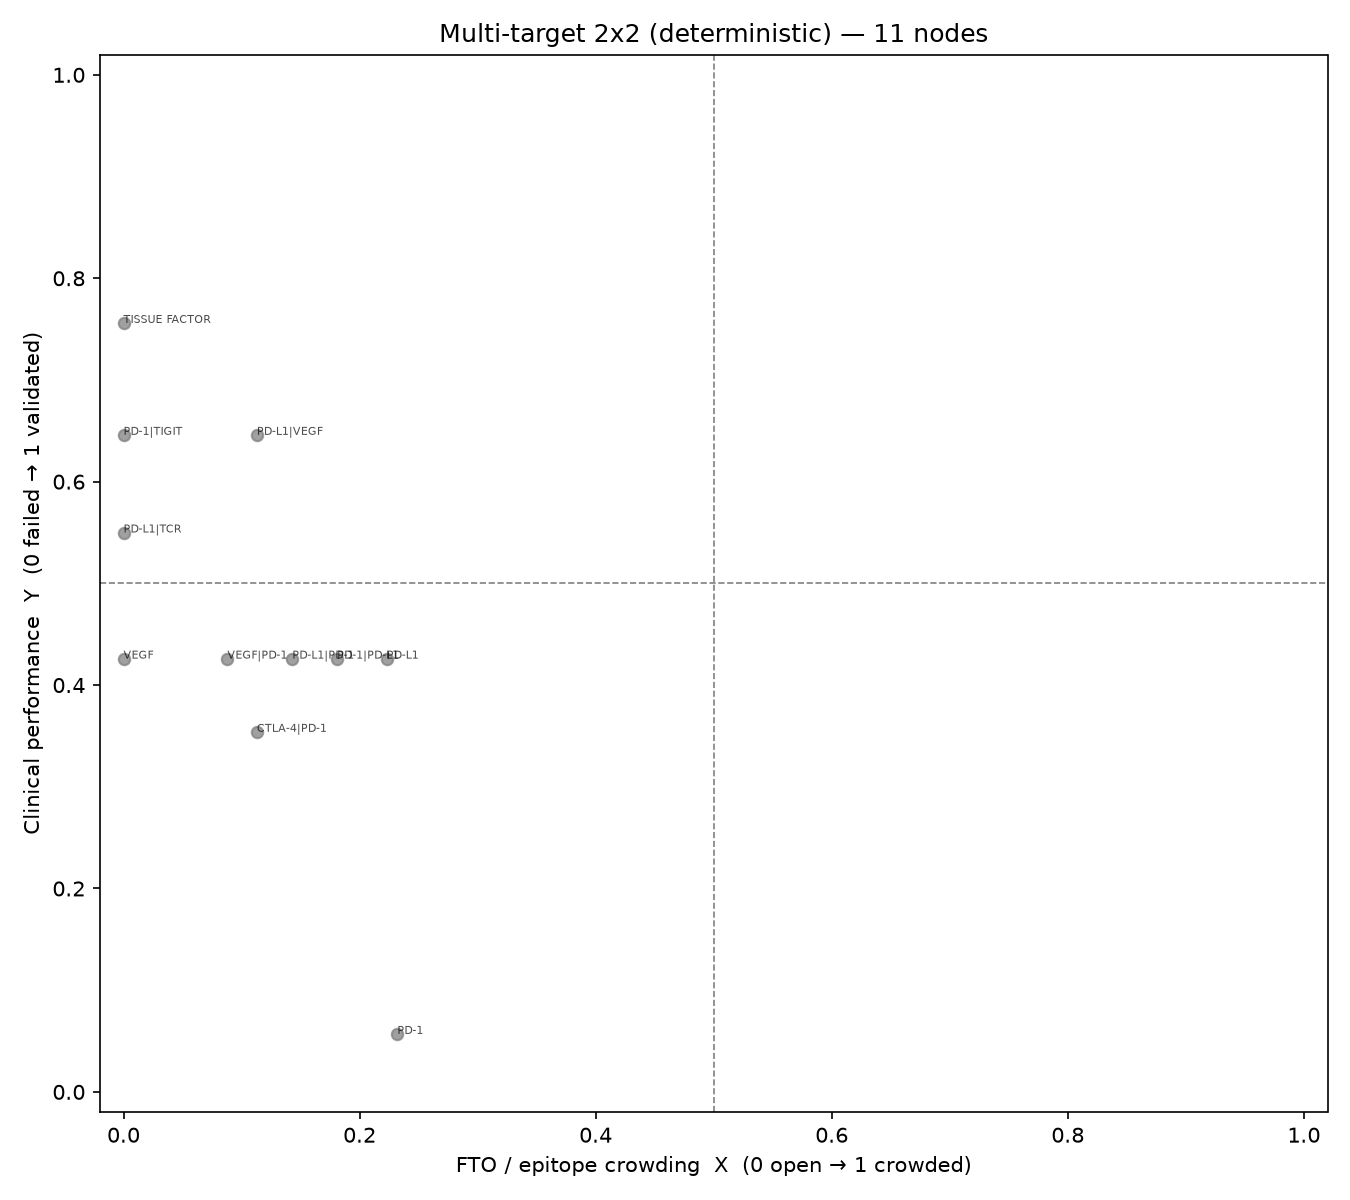

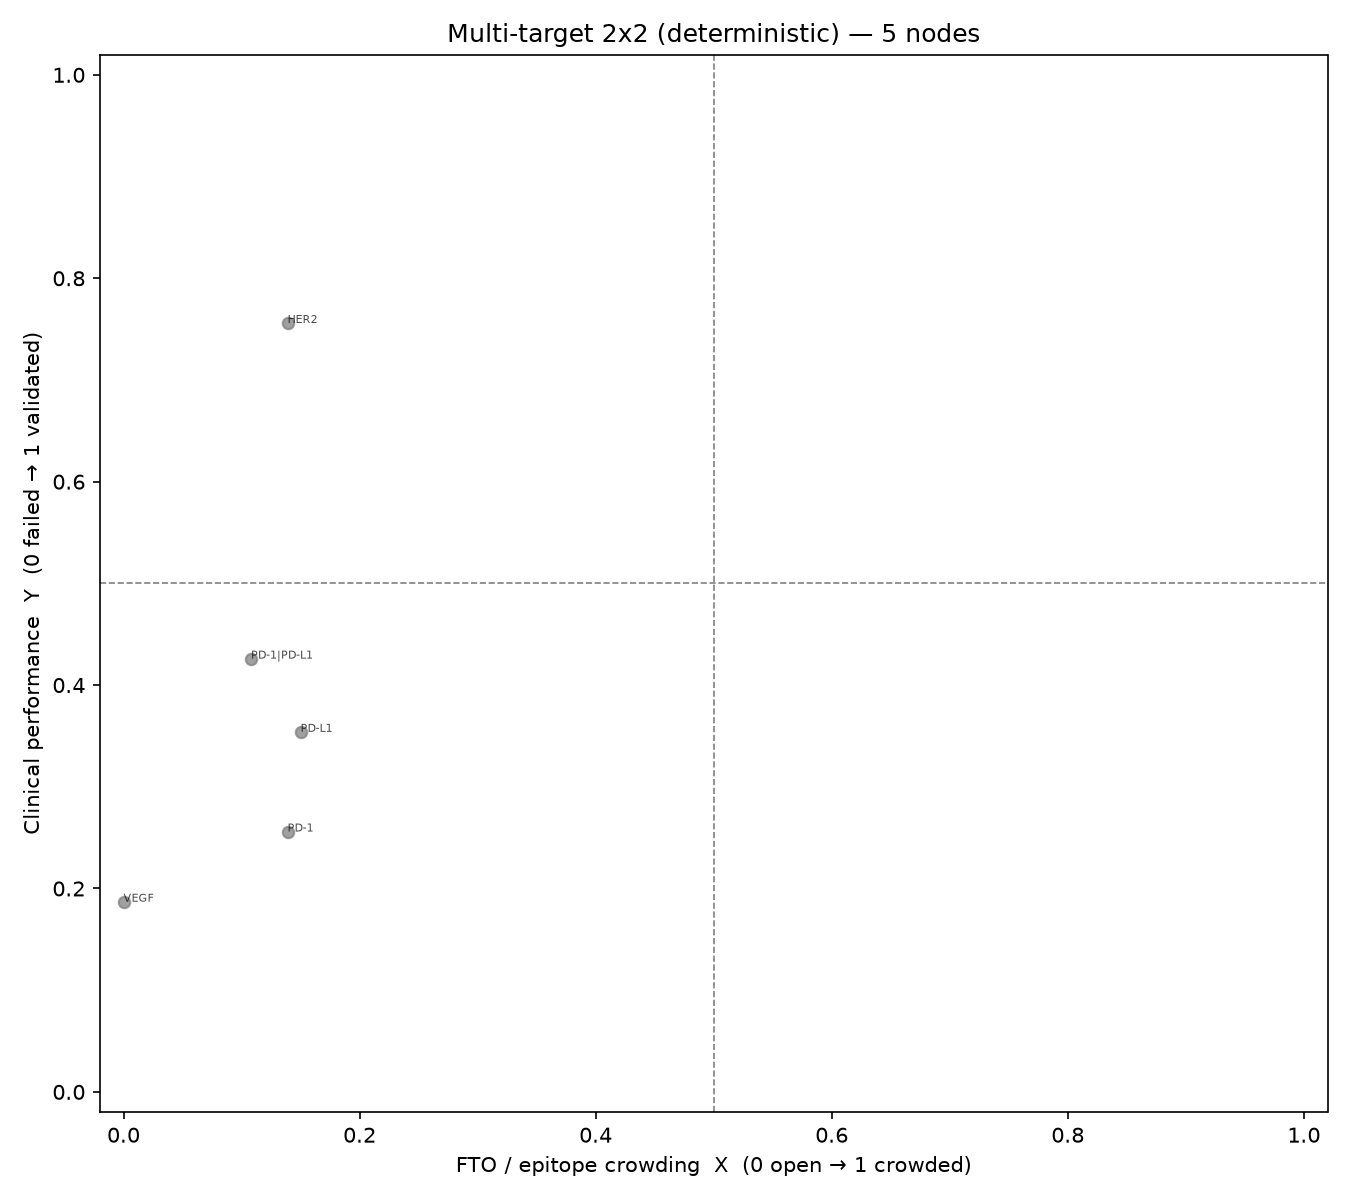

In [12]:
already_run = {"Pancreatic", "Prostate"}
tumor_order = (clin_scoped[clin_scoped["tumor_primary"].isin(NAMED_SOLID_TUMORS)]
               ["tumor_primary"].value_counts().index.tolist())
remaining_tumors = [t for t in tumor_order if t not in already_run]
print(f"Running {len(remaining_tumors)} remaining named solid tumor types, ranked by trial volume:")
print(remaining_tumors)

sweep_summaries = []
for t in remaining_tumors:
    run_name = re.sub(r"[^A-Za-z0-9]+", "_", t).lower()
    master_df, n_rows = analyze_tumor_cut(run_name, t, TUMOR_INDICATION_TERMS[t], clin_scoped)
    summ = summarize_cut(master_df, run_name, t, os.path.join(RUNS_DIR, run_name))
    summ["tumor_type"] = t
    summ["n_input_rows"] = n_rows
    sweep_summaries.append(summ)

    line_counts = clin_scoped[clin_scoped["tumor_primary"] == t]["m_line_of_therapy"].value_counts()
    for line in ("1L", "2L"):
        if line_counts.get(line, 0) >= MIN_LINE_ROWS:
            sub_name = f"{run_name}_{line.lower()}"
            sub_master, n_sub = analyze_tumor_cut(sub_name, t, TUMOR_INDICATION_TERMS[t], clin_scoped, line_filter=line)
            sub_summ = summarize_cut(sub_master, sub_name, f"{t} {line}", os.path.join(RUNS_DIR, sub_name),
                                      show_tables=False, show_chart=False)
            sub_summ["tumor_type"] = f"{t} {line}"
            sub_summ["n_input_rows"] = n_sub
            sweep_summaries.append(sub_summ)

print(f"\\nSweep complete: {len(sweep_summaries)} cuts run (tumor types + qualifying 1L/2L sub-cuts).")

## Entry 13: Cross-Tumor Consolidated Summary

In [13]:
from collections import Counter

pancreatic_tws = pancreatic_master[(pancreatic_master["x_resolved"] & pancreatic_master["y_resolved"]) &
                                    (pancreatic_master["quadrant"] == "TRUE WHITE SPACE")]["target_harmonized"].tolist()

all_cuts = {"Pancreatic": pancreatic_tws, "Prostate": prostate_summary["tws_targets"]}
for s in sweep_summaries:
    all_cuts[s["tumor_type"]] = s["tws_targets"]

sweep_rows = [{"tumor_type": "Pancreatic",
               "n_input_rows": len(clin_scoped[clin_scoped["tumor_primary"] == "Pancreatic"]),
               "n_nodes": len(pancreatic_master),
               "n_placed": int((pancreatic_master["x_resolved"] & pancreatic_master["y_resolved"]).sum()),
               "n_tws": len(pancreatic_tws), "top_tws": ", ".join(pancreatic_tws[:5])}]
sweep_rows.append({"tumor_type": "Prostate", "n_input_rows": n_prostate_rows,
                    "n_nodes": prostate_summary["n_nodes"], "n_placed": prostate_summary["n_placed"],
                    "n_tws": prostate_summary["n_tws"], "top_tws": ", ".join(prostate_summary["top_tws"])})
for s in sweep_summaries:
    sweep_rows.append({"tumor_type": s["tumor_type"], "n_input_rows": s["n_input_rows"],
                       "n_nodes": s["n_nodes"], "n_placed": s["n_placed"], "n_tws": s["n_tws"],
                       "top_tws": ", ".join(s["top_tws"])})

cross_tumor_summary = pd.DataFrame(sweep_rows).sort_values("n_input_rows", ascending=False)
display(cross_tumor_summary, name="cross_tumor_sweep_summary")

tws_counter = Counter(tgt for lst in all_cuts.values() for tgt in lst)
recurring_tws = pd.DataFrame(
    [{"target_harmonized": t, "n_tumor_cuts_as_TWS": n,
      "tumor_types": ", ".join(k for k, v in all_cuts.items() if t in v)}
     for t, n in tws_counter.items() if n >= 2]
).sort_values("n_tumor_cuts_as_TWS", ascending=False)
print(f"Targets flagged TRUE WHITE SPACE in >=2 tumor-type cuts (strongest cross-indication bets): {len(recurring_tws)}")
if len(recurring_tws):
    display(recurring_tws, name="recurring_true_whitespace_targets")

Targets flagged TRUE WHITE SPACE in >=2 tumor-type cuts (strongest cross-indication bets): 25


,tumor_type,n_input_rows,n_nodes,n_placed,n_tws,top_tws
2,NSCLC,2355,1424,50,16,"PD-1, PD-L1, TROP-2-DXD, VEGF, PD-1|VEGF"
5,Breast,1820,1288,43,13,"HER2, HER2-DXD, HER3|HER2, EPCAM|CD3, HER2-DUOCARMYCIN"
8,Colorectal,1101,1261,19,6,"EGFR, PD-L1|VEGF, HER2, HER2|EGFR, CTLA-4|PD-1"
11,Gastric_Esophageal,761,1223,15,8,"CLDN18.2, PD-1|LAG-3, VEGF|PD-1, VEGF, PD-1|PD-L1"
14,Lung_Other,632,1220,23,9,"PD-1, VEGF, PD-L1, HER2-DXD, TROP-2-DXD"
16,HNSCC,586,1183,16,4,"PD-1, PD-1|LAG-3, PD-L1|PD-1, CTLA-4|PD-1"
18,Melanoma,470,1178,15,2,"IGF-1R, PD-1|TCR"
19,Hepatocellular,395,1181,13,1,PD-1|VEGF
20,Ovarian,362,1204,16,4,"VEGF, EPCAM|CD3, CTLA-4|PD-1, PD-1"
21,Glioma_CNS,356,1178,13,2,"VEGF|EGFR, CD40"


,target_harmonized,n_tumor_cuts_as_TWS,tumor_types
5,PD-1,10,"NSCLC, Breast, Gastric_Esophageal, Lung_Other, Lung_Other 1L, HNSCC, HNSCC 1L, Ovarian, SCLC, SCLC 1L"
15,CTLA-4|PD-1,9,"NSCLC, Colorectal, Gastric_Esophageal, Gastric_Esophageal 1L, Lung_Other, HNSCC, Ovarian, Bladder_Urothelial, Sarcoma"
3,VEGF,8,"Prostate, NSCLC, Gastric_Esophageal, Lung_Other, Ovarian, SCLC, SCLC 1L, SCLC 2L"
16,HER2,6,"Breast, Breast 1L, Breast 2L, Colorectal, Bladder_Urothelial, Endometrial_Uterine"
6,PD-L1,6,"NSCLC, NSCLC 1L, Gastric_Esophageal, Lung_Other, SCLC, SCLC 2L"
12,PD-1|PD-L1,5,"NSCLC, NSCLC 1L, Gastric_Esophageal, Bladder_Urothelial, SCLC"
2,PD-1|CTLA-4,5,"Pancreatic, NSCLC, Lung_Other, SCLC, SCLC 2L"
11,EGFR,4,"NSCLC, NSCLC 1L, Colorectal, Biliary_Cholangio"
0,CLDN18.2,4,"Pancreatic, Gastric_Esophageal, Gastric_Esophageal 1L, Biliary_Cholangio"
8,PD-1|VEGF,4,"NSCLC, Colorectal, Lung_Other, Hepatocellular"


## Entry 14: Whole-Dataset Run -- All Tumor Types Combined

Whole-dataset in-scope clinical rows: 16,648 (1,572 distinct targets)
[Whole Dataset (All Tumor Types)] 2463 nodes, 123 placed on 2x2 -- TRUE WHITE SPACE=42 BATTLEGROUND=0 R&D TRAP=81 RED FLAGS=0 | watch-lists: IP-only=516 clinical-only=472
  Top TRUE WHITE SPACE: VEGF, PD-1, PD-L1, TROP-2-DXD, HER2-DXD


,n_targets
quadrant,
TRUE WHITE SPACE,42
BATTLEGROUND,0
R&D TRAP,81
RED FLAGS,0
UNRESOLVED,2340


,target_harmonized,clinical_performance_Y,clinical_label,n_trials,epitope_crowding_X,patents_grounded,blocking_assignee,key_patent
2341,VEGF,1.000,VALIDATED,863,0.000,1,"SUZHOU NEOLOGICS BIOSCIENCE CO., LTD.",WO2025195479A1
1678,PD-1,1.000,VALIDATED,2905,0.139,10,"ABALYTICS ONCOLOGY, INC.",WO2025240670A2
1954,PD-L1,1.000,VALIDATED,788,0.150,12,"EXELIXIS, INC.",WO2026030408A1
2273,TROP-2-DXD,1.000,VALIDATED,17,0.139,10,"ACTINIUM PHARMACEUTICALS, INC.",WO2026055611A1
1231,HER2-DXD,1.000,VALIDATED,22,0.084,4,FUDAN UNIVERSITY,WO2024001844A1
1923,PD-1|VEGF,0.998,VALIDATED,138,0.042,2,"PARAGON THERAPEUTICS, INC.",WO2026064650A1
774,CLDN18.2,0.968,VALIDATED,35,0.066,3,BIOSION INC.,WO2023066267A1
416,CD20|CD3,0.948,VALIDATED,65,0.205,30,"NANJING PROBIO BIOTECH CO., LTD.",WO2026103449A1
2238,TISSUE FACTOR,0.926,VALIDATED,11,0.000,1,"EXELIXIS, INC.",WO2024054821A2
942,DLL3|CD3,0.926,VALIDATED,35,0.139,10,"HAINAN SIMCERE ZAIMING PHARMACEUTICAL CO., LTD.",WO2025146127A1


,target_harmonized,clinical_performance_Y,clinical_label,n_trials,epitope_crowding_X,patents_grounded,blocking_assignee,key_patent
916,CTLA-4|TCR,0.475,CONTESTED,1,0.000,1,"WUXI BIOLOGICS (SHANGHAI) CO., LTD.",WO2020057610A1
1543,MESOTHELIN|TCR,0.475,CONTESTED,1,0.000,1,"ZHEJIANG SHIMAI PHARMACEUTICAL CO., LTD.",WO2023115528A1
781,CLDN18.2-MMAE,0.475,CONTESTED,3,0.042,2,"KEYMED BIOSCIENCES (CHENGDU) CO., LTD",WO2025088105A1
1688,PD-1-MAYTANSINOID,0.475,CONTESTED,1,0.000,1,"GENEQUANTUM HEALTHCARE (SUZHOU) CO., LTD.",WO2024213091A1
120,B7-H3|CD3,0.475,CONTESTED,2,0.000,1,DEUTSCHES KREBSFORSCHUNGSZENTRUM STIFTUNG DES ÖFFENTLICHEN RECHTS,WO2021099347A1
1538,MESOTHELIN|CD3,0.475,CONTESTED,2,0.108,6,"THE UNITED STATES OF AMERICA, AS REPRESENTED BY THE SECRETARY",WO2025171238A1
1691,PD-1-PBD,0.475,CONTESTED,1,0.000,1,"GENEQUANTUM HEALTHCARE (SUZHOU) CO., LTD.",WO2024213091A1
1857,PD-1|MAGE,0.475,CONTESTED,4,0.000,1,"REGENERON PHARMACEUTICALS, INC.",WO2022266598A1
2117,PTK7-AURISTATIN,0.475,CONTESTED,2,0.000,1,"SICHUAN KELUN-BIOTECH BIOPHARMACEUTICAL CO., LTD.",WO2024078586A1
559,CD38|ICAM1,0.475,CONTESTED,1,0.000,1,"VIRTUOSO BINCO, INC.",WO2020102777A1


,target_harmonized,epitope_crowding_X,patents_grounded,blocking_assignee,key_patent
5,5T4-MMAE,0.0,1,"SALUBRIS BIOTHERAPEUTICS, INC.",WO2024197151A2
6,5T4-MMAF,0.0,1,"SALUBRIS BIOTHERAPEUTICS, INC.",WO2024197151A2
46,ALK|VEGF,0.0,1,"KINTOR PHARMACEUTICAL (GUANGDONG) CO., LTD.",WO2023030433A1
48,ALPP|CD3,0.0,1,"PROMAB BIOTECHNOLOGIES, INC.",WO2021154534A1
59,APLP2|HER2-DM1,0.0,1,"REGENERON PHARMACEUTICALS, INC.",WO2019212965A1
60,APLP2|HER2-DM4,0.0,1,"REGENERON PHARMACEUTICALS, INC.",WO2019212965A1
82,AXL|PD-L1-DOXORUBICIN,0.0,1,CELON PHARMA S.A.,WO2025080151A1
83,AXL|PD-L1-MMAE,0.0,1,CELON PHARMA S.A.,WO2025080151A1
84,AXL|PD-L1-MMAF,0.0,1,CELON PHARMA S.A.,WO2025080151A1
85,AXL|PD-L1-PBD,0.0,1,CELON PHARMA S.A.,WO2025080151A1


,target_harmonized,clinical_performance_Y,clinical_label,n_trials
2346,VEGFR2,1.000,VALIDATED,54
831,CTLA-4,0.999,VALIDATED,142
1548,MET-MMAE,0.989,VALIDATED,12
1298,HER2|PD-1,0.974,VALIDATED,75
2276,TROP-2-KL610023,0.972,VALIDATED,14
1242,HER2-TOP1I,0.970,VALIDATED,11
2421,VEGF|MUC16,0.912,VALIDATED,16
338,CD19|CD22,0.846,VALIDATED,76
1816,PD-1|FGFR,0.774,VALIDATED,11
2429,VEGF|PD-1|PD-L1,0.774,VALIDATED,15


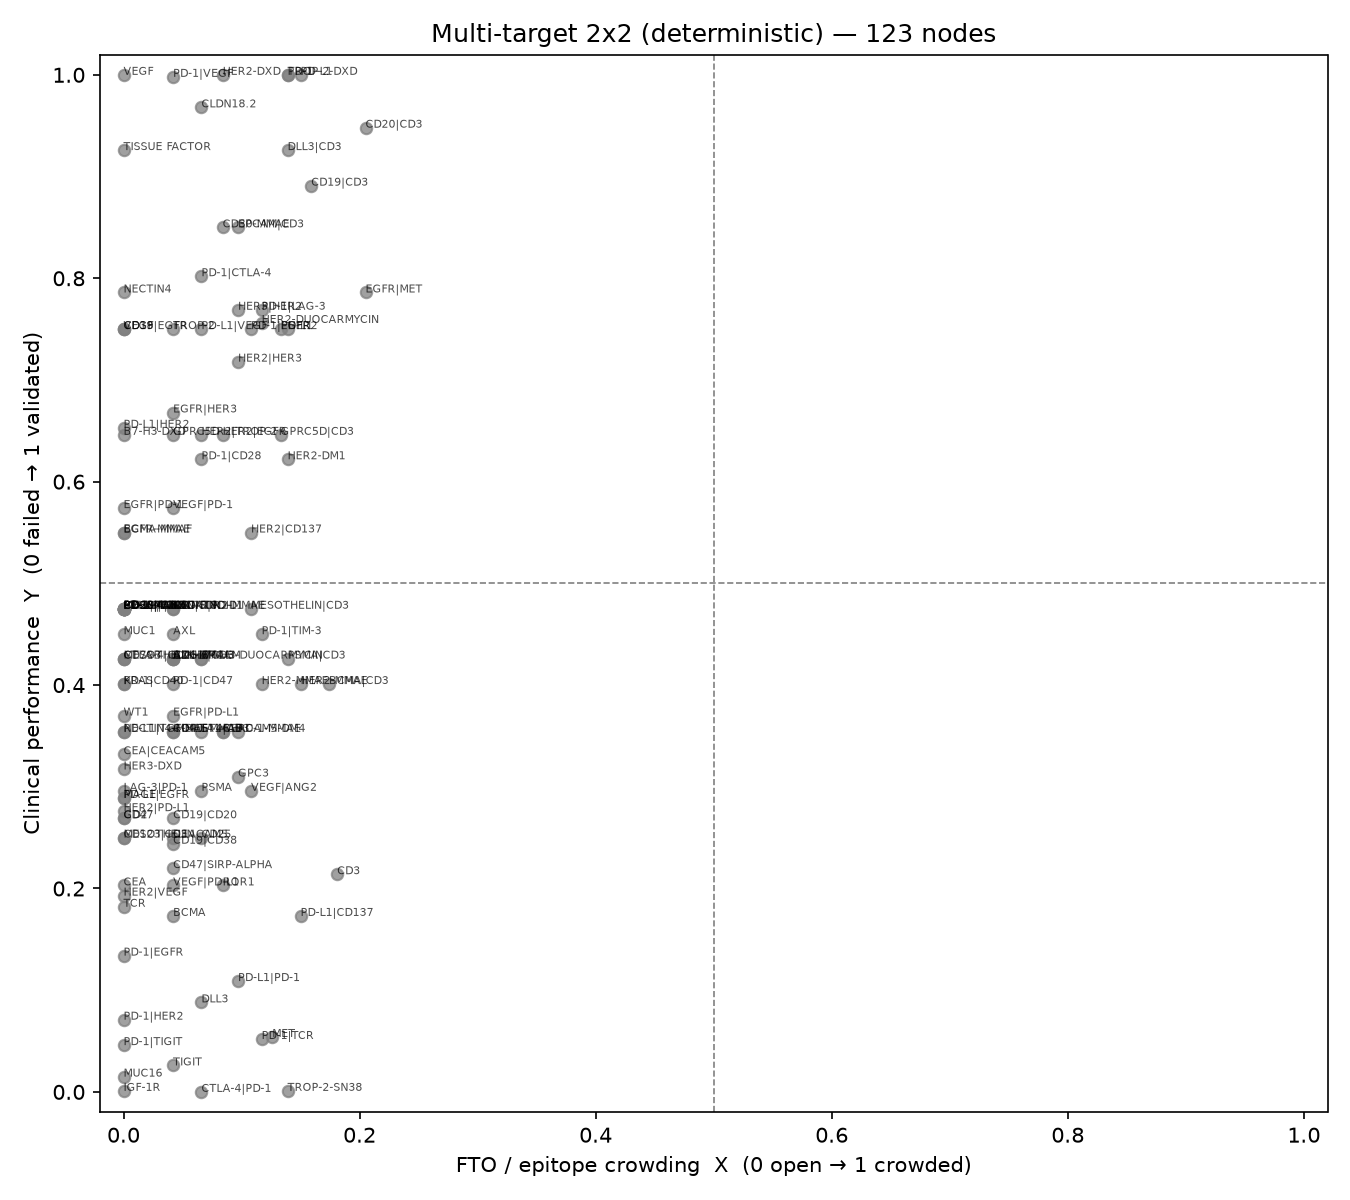

In [14]:
# No tumor filter (tags=None -> every in-scope antibody clinical row, every
# antibody patent). indication_terms=[] deliberately: the IP engine's L3
# layer ("use in THIS indication") only makes sense for a single named
# indication -- at whole-dataset granularity there is no single indication,
# so L3 is intentionally left at 0 for every target and X reduces to
# L1 (cross-modality epitope lock) + L2 (modality claim density) only.
whole_master, n_whole_rows = analyze_tumor_cut("whole_dataset", None, [], clin_scoped)
print(f"Whole-dataset in-scope clinical rows: {n_whole_rows:,} "
      f"({clin_scoped['target_harmonized'].nunique():,} distinct targets)")
whole_summary = summarize_cut(whole_master, "whole_dataset", "Whole Dataset (All Tumor Types)",
                               os.path.join(RUNS_DIR, "whole_dataset"))

## Entry 15: Grand Executive Synthesis -- Portfolio Shortlist

This closes the analysis workflow requested: Pancreatic pilot -> Prostate demo -> full tumor-type sweep (+ line-of-therapy where supported) -> whole dataset -> cross-cut synthesis. Next: PDF / DOCX / PPTX deliverables + notebook DOCX mirror, built by a follow-on report script against this executed notebook.

In [15]:
print("PORTFOLIO SHORTLIST -- ACROSS ALL CUTS (Pancreatic, Prostate, sweep, whole dataset)")
print("=" * 78)
print(f"Whole-dataset view: {whole_summary['n_nodes']} nodes, {whole_summary['n_placed']} placed -- "
      f"TRUE WHITE SPACE={whole_summary['n_tws']} BATTLEGROUND={whole_summary['n_battleground']} "
      f"R&D TRAP={whole_summary['n_rdtrap']} RED FLAGS={whole_summary['n_redflags']}")
if whole_summary["top_tws"]:
    print("  Whole-dataset top TRUE WHITE SPACE: " + ", ".join(whole_summary["top_tws"]))
print()
if len(recurring_tws):
    print("Recommend prioritizing targets validated as TRUE WHITE SPACE across MULTIPLE tumor types")
    print("(broader addressable population, biology de-risked more than once, IP still open):")
    for _, r in recurring_tws.head(10).iterrows():
        print(f"  - {r['target_harmonized']}: {r['n_tumor_cuts_as_TWS']} cuts ({r['tumor_types']})")
else:
    print("No target recurred as TRUE WHITE SPACE across multiple tumor-type cuts in this run --")
    print("cross-indication whitespace bets are indication-specific here, not target-level.")
print()
print(f"Total cuts run this session: Pancreatic, Prostate, {len(sweep_summaries)} sweep cuts, "
      f"Whole Dataset = {2 + len(sweep_summaries) + 1} cuts.")
print("All quadrant tables, watch-lists and charts for every cut are exported under")
print(f"  {OUT_DIR}")

PORTFOLIO SHORTLIST -- ACROSS ALL CUTS (Pancreatic, Prostate, sweep, whole dataset)
Whole-dataset view: 2463 nodes, 123 placed -- TRUE WHITE SPACE=42 BATTLEGROUND=0 R&D TRAP=81 RED FLAGS=0
  Whole-dataset top TRUE WHITE SPACE: VEGF, PD-1, PD-L1, TROP-2-DXD, HER2-DXD

Recommend prioritizing targets validated as TRUE WHITE SPACE across MULTIPLE tumor types
(broader addressable population, biology de-risked more than once, IP still open):
  - PD-1: 10 cuts (NSCLC, Breast, Gastric_Esophageal, Lung_Other, Lung_Other 1L, HNSCC, HNSCC 1L, Ovarian, SCLC, SCLC 1L)
  - CTLA-4|PD-1: 9 cuts (NSCLC, Colorectal, Gastric_Esophageal, Gastric_Esophageal 1L, Lung_Other, HNSCC, Ovarian, Bladder_Urothelial, Sarcoma)
  - VEGF: 8 cuts (Prostate, NSCLC, Gastric_Esophageal, Lung_Other, Ovarian, SCLC, SCLC 1L, SCLC 2L)
  - HER2: 6 cuts (Breast, Breast 1L, Breast 2L, Colorectal, Bladder_Urothelial, Endometrial_Uterine)
  - PD-L1: 6 cuts (NSCLC, NSCLC 1L, Gastric_Esophageal, Lung_Other, SCLC, SCLC 2L)
  - PD-1|P

## Entry 16: Per-Tumor-Type 2x2 Classification -- Consolidated Ledger

Consolidated view of every per-tumor-type 2x2 cut already run in Entries 5-9/11/12, one table + one printed block per tumor-type name with its classified targets listed underneath. Appended here (rather than inserted earlier) to avoid renumbering already-referenced entries.

In [16]:
# One single, easy-to-read reference: for every named solid tumor type run in
# this notebook (Entries 5-9 Pancreatic, 11 Prostate, 12 the sweep), list every
# target that landed on the 2x2 (both axes resolved) together with its quadrant
# classification, grouped under the tumor-type name. Reads each cut's own
# master_multitarget_whitespace.csv straight off disk (already written by
# MTW.run() earlier in this notebook) -- no recomputation, exact same numbers.
ledger_rows = []
for t in NAMED_SOLID_TUMORS:
    slug = re.sub(r"[^A-Za-z0-9]+", "_", t).lower()
    master_csv = os.path.join(RUNS_DIR, slug, "master_multitarget_whitespace.csv")
    if not os.path.exists(master_csv):
        continue
    m = pd.read_csv(master_csv)
    placed = m[(m["x_resolved"] == True) & (m["y_resolved"] == True)].copy()  # noqa: E712
    placed.insert(0, "tumor_type", t)
    ledger_rows.append(placed[["tumor_type", "target_harmonized", "quadrant",
                                "clinical_performance_Y", "clinical_label", "n_trials",
                                "epitope_crowding_X", "patents_grounded", "blocking_assignee"]])

tumor_2x2_ledger = pd.concat(ledger_rows, ignore_index=True)
tumor_2x2_ledger = tumor_2x2_ledger.sort_values(
    ["tumor_type", "quadrant", "clinical_performance_Y"], ascending=[True, True, False])
display(tumor_2x2_ledger, name="tumor_2x2_classification_ledger")

print(f"Consolidated ledger: {len(tumor_2x2_ledger)} placed target-x-tumor rows across "
      f"{tumor_2x2_ledger['tumor_type'].nunique()} named solid tumor types.")
print("Full detail (all columns, all rows): data/tumor_2x2_classification_ledger.csv")
print()

for t in NAMED_SOLID_TUMORS:
    sub = tumor_2x2_ledger[tumor_2x2_ledger["tumor_type"] == t]
    if not len(sub):
        continue
    print(f"=== {t} ({len(sub)} placed targets) ===")
    counts = sub["quadrant"].value_counts()
    for q in MTW.W.ALL_QUADRANTS:
        n_q = int(counts.get(q, 0))
        if n_q:
            names = ", ".join(sub[sub["quadrant"] == q]["target_harmonized"].tolist())
            print(f"  {q} ({n_q}): {names}")
        else:
            print(f"  {q} (0):")
    print()

Consolidated ledger: 317 placed target-x-tumor rows across 19 named solid tumor types.
Full detail (all columns, all rows): data/tumor_2x2_classification_ledger.csv

=== NSCLC (50 placed targets) ===
  TRUE WHITE SPACE (16): PD-1, PD-L1, TROP-2-DXD, VEGF, PD-1|VEGF, HER2-DXD, EGFR|MET, HER2|HER3, EGFR, PD-1|PD-L1, TISSUE FACTOR, HER2|TROP-2, PD-1|CTLA-4, PD-1|LAG-3, CTLA-4|PD-1, EGFR|HER3
  BATTLEGROUND (0):
  R&D TRAP (34): B7-H3|CD3, GPC3, PD-1-MAYTANSINOID, PD-1|CD40, PD-1|HER2, PTK7-AURISTATIN, TROP-2, MESOTHELIN, PD-1|TIM-3, AXL-MMAE, B7-H3-DUOCARMYCIN, B7-H4|CD3, CD3, CD38, CD40, CEACAM5, ROR1, HER3-DXD, 5T4|CD3, CEACAM5-DM4, HER2|EGFR, PD-L1|EGFR, PD-L1|VEGF, ROR1-MMAE, PD-L1|PD-1, MET, PD-1|EGFR, VEGF|EGFR, PD-L1|CD137, PD-1|TIGIT, TIGIT, IGF-1R, HER2, TROP-2-SN38
  RED FLAGS (0):

=== SCLC (13 placed targets) ===
  TRUE WHITE SPACE (7): VEGF, DLL3|CD3, PD-1, PD-L1, PD-1|PD-L1, B7-H3-DXD, PD-1|CTLA-4
  BATTLEGROUND (0):
  R&D TRAP (6): CTLA-4|PD-1, PD-1|HER2, PD-1|VEGF, TIGIT, 

,tumor_type,target_harmonized,quadrant,clinical_performance_Y,clinical_label,n_trials,epitope_crowding_X,patents_grounded,blocking_assignee
210,Biliary_Cholangio,CTLA-4|PD-1,R&D TRAP,0.426,CONTESTED,5,0.066,3,MEDIMMUNE LLC
211,Biliary_Cholangio,PD-1|TIGIT,R&D TRAP,0.426,CONTESTED,1,0.000,1,"MEDIMMUNE, LLC"
212,Biliary_Cholangio,PD-L1,R&D TRAP,0.426,CONTESTED,23,0.150,12,"EXELIXIS, INC."
213,Biliary_Cholangio,PD-1|PD-L1,R&D TRAP,0.401,CONTESTED,9,0.108,6,BIOTHEUS INC.
214,Biliary_Cholangio,PD-1,R&D TRAP,0.289,FAILED / CONTESTED (late),51,0.139,10,"ABALYTICS ONCOLOGY, INC."
208,Biliary_Cholangio,CLDN18.2,TRUE WHITE SPACE,0.646,VALIDATED,1,0.066,3,BIOSION INC.
209,Biliary_Cholangio,EGFR,TRUE WHITE SPACE,0.646,VALIDATED,8,0.133,9,"SHANGHAI RUOTUO BIOSCIENCES CO., LTD."
240,Bladder_Urothelial,NECTIN4,R&D TRAP,0.450,CONTESTED,22,0.000,1,ELPIS BIOPHARMACEUTICALS
241,Bladder_Urothelial,EGFR,R&D TRAP,0.426,CONTESTED,2,0.179,9,"SHANGHAI RUOTUO BIOSCIENCES CO., LTD."
242,Bladder_Urothelial,PD-L1|VEGF,R&D TRAP,0.426,CONTESTED,1,0.066,3,"SHANGHAI HENLIUS BIOTECH, INC."
